<a href="https://colab.research.google.com/github/vanislekahuna/wps-labs/blob/main/Bayesian_Wildfire_Stats_Lab/%5BPart_2%5DPutting_DAGs_to_the_Test_What_Regression_reveals_about_Wildfire_Drivers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Putting DAGs to the Test: What Regression Reveals about Wildfire Drivers (Part 2)**

<img src="https://images.unsplash.com/photo-1732089784928-d1a4cac61912?q=80&w=876&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D" width=725 height=480>

[Source](https://unsplash.com/photos/a-group-of-people-with-backpacks-and-shovels-in-the-woods-srKR5P-Mh0E)

## **Introduction**

Late April 2026 saw Metro Vancouver temperatures soar to 28°C, ten degrees above seasonal averages, capping the first snowless winter the region has experienced in 43 years (Shepert, 2026). Across the province, snowpack levels tell a concerning story: Vancouver Island sits at just 27% of normal, the South Coast at 45%, and the Okanagan at 31% (CBC News, 2026). These conditions matter for wildfire risk because snowpack acts as a natural moisture reservoir through spring and summer. When it's absent or depleted early, soils dry out faster and fuel conditions become more conducive to fire spread. The BC Wildfire Service's spring outlook warns of elevated risk for extreme or difficult-to-control wildfires in the northeast, Chilcotin, and South Thompson regions, with the severity of the 2026 season hinging largely on precipitation through May and June (BC Wildfire Service, 2026).

This isn't abstract climate modeling. Higher-than-normal winter freezing levels have already resulted in record-low snow at valley bottoms, increasing the likelihood of early-season grass fires, especially in the Interior valleys. When fire managers make resource allocation decisions such as where to pre-position crews, when to issue high-danger warnings, how to staff seasonal operations, they're working with limited information about which atmospheric conditions actually drive large fire growth.

And this, ladies and gentlemen, is when causal inference matters. Understanding what causes fires to grow beyond initial attack capacity isn't the same as predicting fire behavior in real-time. However it does tell us which atmospheric signals to monitor, which conditions create the highest risk, and where the "controllable variance" lives in a system dominated by chaos and suppression response. Even modest insights such as temperature's effect, humidity's role, or precipitation's dampening power, translate directly into operational decisions that protect communities and ecosystems.

In [Part 1](https://medium.com/towards-artificial-intelligence/rethinking-predictors-why-causal-reasoning-matters-in-data-science-part-1-f1d4c1e08068), we built a causal hypothesis using a Directed Acyclic Graph (DAG) to map how atmospheric conditions might influence wildfire size in BC. Temperature and precipitation were hypothesized to be root causes in our data, with their effects flowing through mediators like soil moisture and humidity VPD.

In [1]:
%%capture

## Install the following libraries if necessary:
# !pip install arviz==0.20.0
# !pip install matplotlib==3.8.0
# !pip install pandas==2.2.2
# !pip install pymc==5.19.1
# !pip install scipy==1.13.1

In [2]:
import requests
import sqlite3
import arviz as az
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import networkx as nx
import pandas as pd
import pymc as pm
import seaborn as sns
import scipy.stats as stats

from matplotlib.patches import FancyArrowPatch
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from pathlib import Path
from typing import Optional, Tuple

In [3]:
%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 824
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")
az.rcParams["stats.hdi_prob"] = 0.89  # sets default credible interval used by arviz

/usr/local/lib/python3.12/dist-packages/arviz/rcparams.py:345: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(


/tmp/ipykernel_4395/2542002290.py:166: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


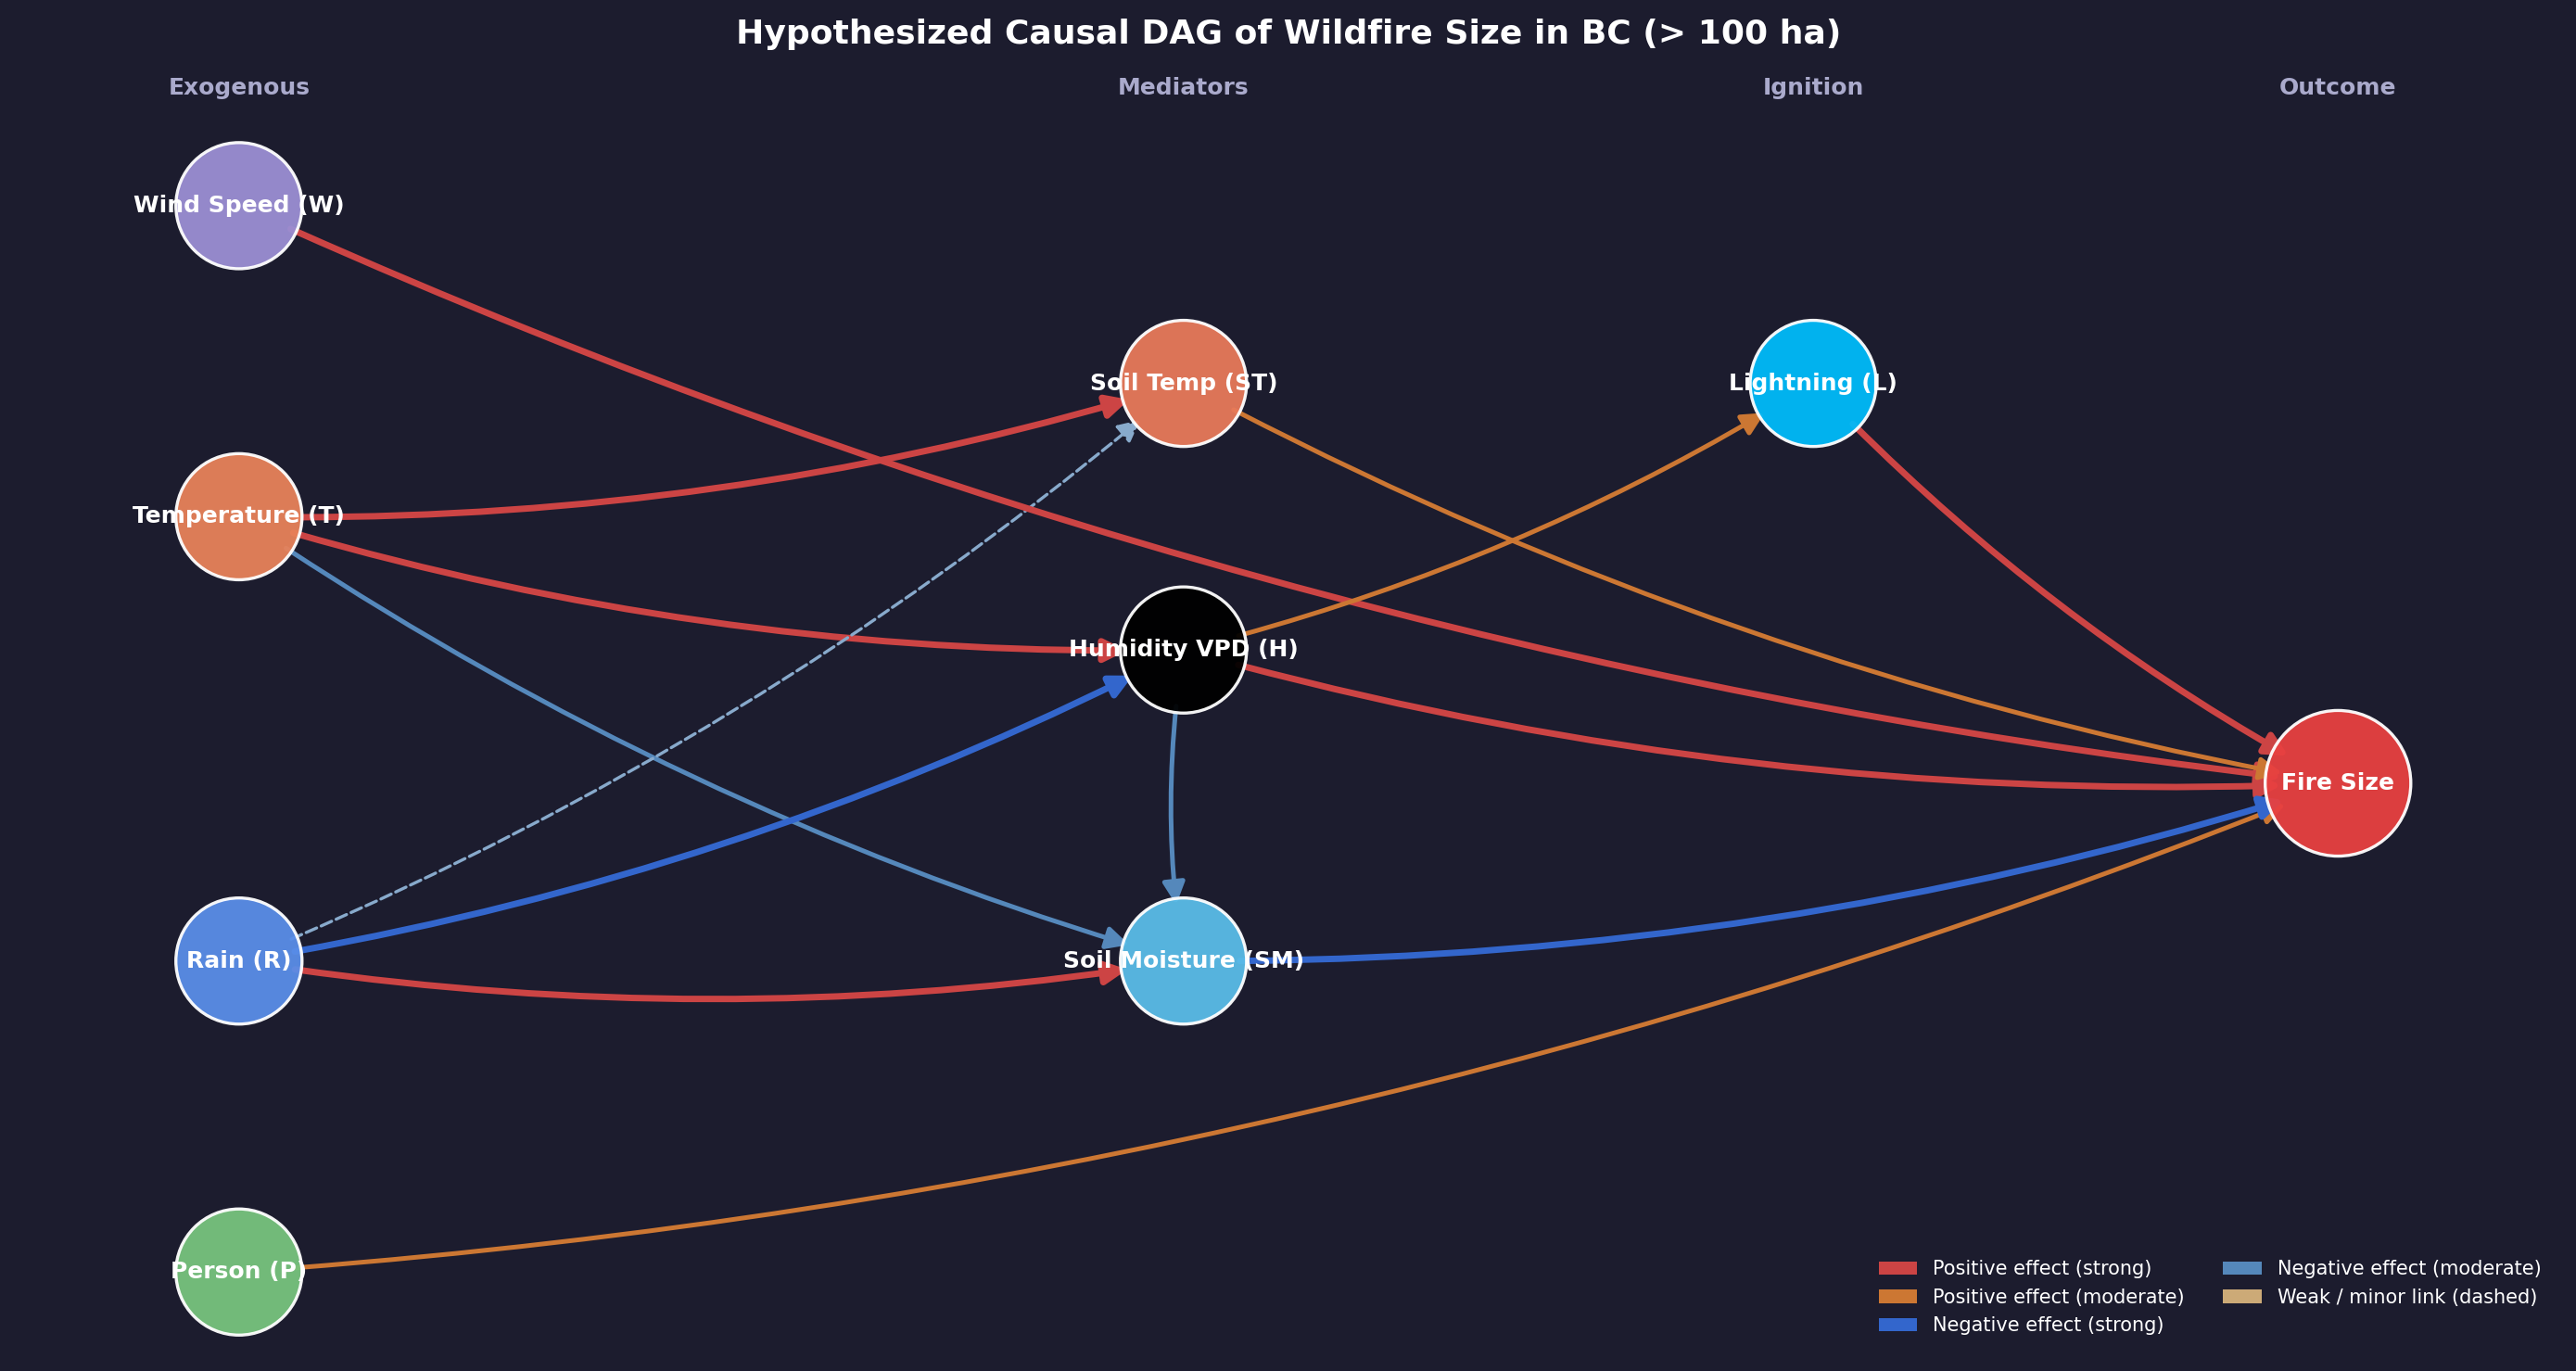

In [4]:
# ── Build the DAG ─────────────────────────────────────────────────────────────
G = nx.DiGraph()

# Node groups
exogenous   = ["Temperature (T)", "Rain (R)", "Wind Speed (W)", "Person (P)"]
mediators   = ["Humidity VPD (H)", "Soil Moisture (SM)", "Soil Temp (ST)"]
ignition    = ["Lightning (L)"]
outcome     = ["Fire Size"]

all_nodes = exogenous + mediators + ignition + outcome
G.add_nodes_from(all_nodes)

# Edges: (source, target, sign, strength)
edges = [
    # Temperature pathways
    ("Temperature (T)",   "Humidity VPD (H)", "+", "strong"),
    ("Temperature (T)",   "Soil Temp (ST)","+", "strong"),
    ("Temperature (T)",   "Soil Moisture (SM)", "-", "moderate"),

    # Precipitation pathways
    ("Rain (R)", "Humidity VPD (H)", "-", "strong"),
    ("Rain (R)", "Soil Moisture (SM)",  "+", "strong"),
    ("Rain (R)", "Soil Temp (ST)","-", "weak"),

    # VPD downstream
    ("Humidity VPD (H)", "Soil Moisture (SM)",  "-", "moderate"),
    ("Humidity VPD (H)", "Lightning (L)",      "+", "moderate"),

    # Direct effects on Fire Size
    ("Wind Speed (W)",      "Fire Size",    "+", "strong"),
    ("Humidity VPD (H)", "Fire Size",    "+", "strong"),
    ("Soil Moisture (SM)",   "Fire Size",    "-", "strong"),
    ("Soil Temp (ST)","Fire Size",    "+", "moderate"),
    ("Lightning (L)",       "Fire Size",    "+", "strong"),
    ("Person (P)",          "Fire Size",    "+", "moderate"),
]

for src, tgt, sign, strength in edges:
    G.add_edge(src, tgt, sign=sign, strength=strength)

# ── Layout ────────────────────────────────────────────────────────────────────
# Manual positions for legibility
pos = {
    # Exogenous — left column
    "Temperature (T)":    (0.0, 0.75),
    "Rain (R)":  (0.0, 0.25),
    "Wind Speed (W)":     (0.0, 1.10),
    "Person (P)":         (0.0, -0.10),

    # Mediators — centre column
    "Humidity VPD (H)":            (0.45, 0.60),
    "Soil Moisture (SM)":  (0.45, 0.25),
    "Soil Temp (ST)":(0.45, 0.90),

    # Ignition — right-centre
    "Lightning (L)":      (0.75, 0.90),

    # Outcome — far right
    "Fire Size":      (1.0,  0.45),
}

# ── Colours & style ───────────────────────────────────────────────────────────
node_colours = {
    "Temperature (T)":     "#E8825A",
    "Rain (R)":            "#5A8EE8",
    "Wind Speed (W)":      "#9B8FD4",
    "Person (P)":          "#78C47E",
    "Humidity VPD (H)":    "#000000",
    "Soil Moisture (SM)":  "#5ABCE8",
    "Soil Temp (ST)":      "#E87A5A",
    "Lightning (L)":       "#00BBFA",
    "Fire Size":           "#E84040",
}

edge_colours = {
    ("+", "strong"):   "#CC4444",
    ("+", "moderate"): "#CC7733",
    ("+", "weak"):     "#CCAA77",
    ("-", "strong"):   "#3366CC",
    ("-", "moderate"): "#5588BB",
    ("-", "weak"):     "#88AACC",
}

edge_styles = {
    "strong":   "solid",
    "moderate": "solid",
    "weak":     "dashed",
}

edge_widths = {"strong": 2.5, "moderate": 1.8, "weak": 1.2}

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7.5))
fig.patch.set_facecolor("#1C1C2E")
ax.set_facecolor("#1C1C2E")

# Draw nodes
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_size=[3200 if n == "Fire Size" else 2400 for n in G.nodes()],
    node_color=[node_colours[n] for n in G.nodes()],
    edgecolors="#FFFFFF", linewidths=1.2,
    alpha=0.95,
)

# Draw edges individually to control style
for src, tgt, data in G.edges(data=True):
    sign     = data["sign"]
    strength = data["strength"]
    colour   = edge_colours[(sign, strength)]
    style    = edge_styles[strength]
    width    = edge_widths[strength]

    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edgelist=[(src, tgt)],
        edge_color=colour,
        style=style,
        width=width,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=18,
        connectionstyle="arc3,rad=0.08",
        min_source_margin=22,
        min_target_margin=22,
    )

# Labels
nx.draw_networkx_labels(
    G, pos, ax=ax,
    font_size=9,
    font_color="#FFFFFF",
    font_weight="bold",
)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor="#CC4444", label="Positive effect (strong)"),
    mpatches.Patch(facecolor="#CC7733", label="Positive effect (moderate)"),
    mpatches.Patch(facecolor="#3366CC", label="Negative effect (strong)"),
    mpatches.Patch(facecolor="#5588BB", label="Negative effect (moderate)"),
    mpatches.Patch(facecolor="#CCAA77", label="Weak / minor link (dashed)")
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=7.5,
    framealpha=0.25,
    facecolor="#2A2A40",
    edgecolor="#FFFFFF",
    labelcolor="#FFFFFF",
    ncol=2,
)

# Column annotations
for x, label in [(0.0, "Exogenous"), (0.45, "Mediators"), (0.75, "Ignition"), (1.0, "Outcome")]:
    ax.text(x, 1.22, label, ha="center", va="bottom", fontsize=9,
            color="#AAAACC", fontweight="bold", transform=ax.transData)

ax.set_title(
    "Hypothesized Causal DAG of Wildfire Size in BC (> 100 ha)",
    color="#FFFFFF", fontsize=13, fontweight="bold", pad=30,
)
ax.axis("off")
plt.tight_layout()

We then fitted some regression models that we’ll be sharing in this article to test our hypothesis and found some interesting results. Some hypotheses held up and others collapsed when confronted with data. Temperature's effect turned out weaker and less consistent than expected. Soil conditions proved to be redundant mediators adding noise rather than signal. And fitting separate models by fire zone revealed massive geographic variation in how atmospheric factors influence fire growth which challenged my assumption of there being a single, province-wide causal structure.

In this article, we’ll be documenting the process of fitting multiple linear regression models to a historical dataset consisting of about 4,000 large BC wildfires (by large, we mean those that have burned over 100 hectares), testing our DAG assumptions, and revising our causal understanding based on the evidence. We'll end up with R² score of roughly `0.11` which is modest by predictive standards, but meaningful for understanding the atmospheric component of fire growth. That 11% represents the portion of fire size determined by weather conditions at ignition, as opposed to post-ignition factors like suppression timing, fuel availability, topographic interactions, and stochastic spread patterns. And to be precise about scope: Every finding in this article is conditional on fires that exceeded 100 hectares. Our causal estimand is the association between atmospheric conditions and fire size among large fires, not what drives a fire to become large in the first place. These are related but distinct questions, and the conclusions here shouldn't be generalised to the broader population of BC wildfires.

And to be abundantly transparent here: This isn't a forecast model. The goal of this project is to gain a causal understanding of which atmospheric conditions have real effects on fire size, learning how strong those effects are, and what our atmospheric predictors tell us about the mechanisms driving large wildfires. For fire managers operating in the uncertainty of a spring where "little or no skill in long-range precipitation forecasting" exists,  understanding even 11% of the variance matters when that 11% is the part you can monitor, anticipate, and respond to.

Recall that this article represents Part 2 of a two-part series. For the full DAG construction, theoretical framework, and why we're focusing on causal inference rather than prediction, check out our article [here](https://medium.com/towards-artificial-intelligence/rethinking-predictors-why-causal-reasoning-matters-in-data-science-part-1-f1d4c1e08068) on Part 1. Let’s begin.

## **Feature Engineering**

First we’ll extract data from the dataset we engineered and documented [here](https://medium.com/towards-artificial-intelligence/how-to-augment-wildfire-datasets-with-historical-weather-data-using-python-and-google-earth-engine-eae4c2a73650) to get it ready for analysis:

In [5]:
db_link = "https://raw.githubusercontent.com/vanislekahuna/wps-labs/main/data/historical_bc_wildfires/bc_wildfires.db"
response = requests.get(db_link)
with open("bc_wildfires.db", "wb") as f:
    f.write(response.content)

conn = sqlite3.connect('bc_wildfires.db')
cursor = conn.cursor()

In [6]:
join_query = """
WITH weather AS (
    SELECT wind_speed_ms, wind_direction_deg, wind_direction, temperature_c AS temp_c_ign_date, humidity_dewpoint_temperature_2m AS humidity_dewpoint_temp_k_ign_date, soil_temperature_level_1 AS soil_temp_lvl1_ign_date, fire_label AS weather_fire_label
    FROM weather_data
),
terraclimate AS (
    SELECT monthly_mean_temp_c, monthly_total_precip_mm, monthly_mean_humidity_vpd_kPa, monthly_mean_soil_moisture_mm, fire_label AS terraclimate_fire_label
    FROM terraclimate_bc_weather
)
SELECT *
FROM historical_bc_wildfires
LEFT JOIN weather ON historical_bc_wildfires.FIRELABEL = weather.weather_fire_label
LEFT JOIN terraclimate ON historical_bc_wildfires.FIRELABEL = terraclimate.terraclimate_fire_label
WHERE historical_bc_wildfires.SIZE_HA IS NOT NULL
AND historical_bc_wildfires.SIZE_HA > 0
AND historical_bc_wildfires.FIRELABEL NOT IN ('1951-R00037', '1951-R00050', '1951-R00060', '1951-R00067', '1951-R00069', '1951-R00070', '1956-R00107', '1958-V00283', '1956-R00160', '1968-R00088', '1985-V70083', '1985-V70088', '1987-V90016', '1990-V50012');
"""

df = pd.read_sql_query(join_query, conn)

print(f"DataFrame shape: {df.shape} \n\n \
Columns: {df.columns} \n")

df.head()

DataFrame shape: (162905, 33) 

 Columns: Index(['FIRE_NO', 'FIRE_YEAR', 'RSPNS_TYPC', 'IGN_DATE', 'FR_T_DTE',
       'FIRE_CAUSE', 'FIRELABEL', 'FRCNTR', 'ZONE', 'FIRE_ID', 'FIRE_TYPE',
       'INCDNT_NM', 'GEO_DESC', 'LATITUDE', 'LONGITUDE', 'SIZE_HA', 'FCODE',
       'SHAPE', 'OBJECTID', 'X_COORDINATE', 'Y_COORDINATE', 'wind_speed_ms',
       'wind_direction_deg', 'wind_direction', 'temp_c_ign_date',
       'humidity_dewpoint_temp_k_ign_date', 'soil_temp_lvl1_ign_date',
       'weather_fire_label', 'monthly_mean_temp_c', 'monthly_total_precip_mm',
       'monthly_mean_humidity_vpd_kPa', 'monthly_mean_soil_moisture_mm',
       'terraclimate_fire_label'],
      dtype='object') 



,FIRE_NO,FIRE_YEAR,RSPNS_TYPC,IGN_DATE,FR_T_DTE,FIRE_CAUSE,FIRELABEL,FRCNTR,ZONE,FIRE_ID,...,wind_direction,temp_c_ign_date,humidity_dewpoint_temp_k_ign_date,soil_temp_lvl1_ign_date,weather_fire_label,monthly_mean_temp_c,monthly_total_precip_mm,monthly_mean_humidity_vpd_kPa,monthly_mean_soil_moisture_mm,terraclimate_fire_label
0,V11082,2021,Full,2.021063e+13,2.021063e+13,Person,2021-V11082,2.0,1.0,1082,...,Northwest,24.190454,288.407013,293.928192,2021-V11082,13.90,33.0,82.0,662.0,2021-V11082
1,K50948,2020,Full,2.020080e+13,2.020081e+13,Person,2020-K50948,5.0,5.0,500948,...,East,26.581812,279.547333,296.103882,2020-K50948,18.75,11.0,133.0,182.0,2020-K50948
2,V70735,2021,Full,2.021061e+13,2.021061e+13,Person,2021-V70735,2.0,7.0,735,...,West,14.023950,278.705872,288.122131,2021-V70735,18.00,33.0,78.0,509.0,2021-V70735
3,K20928,2021,Full,2.021063e+13,2.021063e+13,Person,2021-K20928,5.0,2.0,928,...,Northwest,16.139764,282.903931,288.909363,2021-K20928,14.80,23.0,103.0,296.0,2021-K20928
4,V81001,2022,Full,2.022080e+13,2.022080e+13,Person,2022-V81001,2.0,8.0,1001,...,Northwest,13.016840,282.843109,288.308258,2022-V81001,17.70,45.0,60.0,355.0,2022-V81001


In [7]:
wildfire_df = df[
    [
        "FRCNTR",
        "FIRELABEL",
        "IGN_DATE",
        "FIRE_CAUSE",
        "SIZE_HA",
        "wind_speed_ms",
        "temp_c_ign_date",
        "humidity_dewpoint_temp_k_ign_date",
        "soil_temp_lvl1_ign_date",
        "monthly_mean_temp_c",
        "monthly_total_precip_mm",
        "monthly_mean_humidity_vpd_kPa",
        "monthly_mean_soil_moisture_mm"
    ]
  ].copy()

In [8]:
centres = wildfire_df["FRCNTR"].unique()

In [9]:
wildfire_df["size_log1ptransformed"] = np.log1p(wildfire_df["SIZE_HA"])
wildfire_df["wind_speed_log1ptransformed"] = np.log1p(wildfire_df["wind_speed_ms"])
wildfire_df["soil_temp_c_lvl1_ign_date"] = wildfire_df["soil_temp_lvl1_ign_date"] - 273.15

print(f"wildfire_df shape: {wildfire_df.shape} \n")

wildfire_df shape: (162905, 16) 



In [10]:
# print(wildfire_df["FIRE_CAUSE"].value_counts())
one_hot_encodding = pd.get_dummies(wildfire_df["FIRE_CAUSE"], dtype=int)

In [11]:
wildfire_df = pd.concat([wildfire_df, one_hot_encodding], axis=1)

print(f"wildfire_df shape: {wildfire_df.shape} \n")
wildfire_df.head()

wildfire_df shape: (162905, 19) 



,FRCNTR,FIRELABEL,IGN_DATE,FIRE_CAUSE,SIZE_HA,wind_speed_ms,temp_c_ign_date,humidity_dewpoint_temp_k_ign_date,soil_temp_lvl1_ign_date,monthly_mean_temp_c,monthly_total_precip_mm,monthly_mean_humidity_vpd_kPa,monthly_mean_soil_moisture_mm,size_log1ptransformed,wind_speed_log1ptransformed,soil_temp_c_lvl1_ign_date,Lightning,Person,Unknown
0,2.0,2021-V11082,2.021063e+13,Person,0.009,0.238463,24.190454,288.407013,293.928192,13.90,33.0,82.0,662.0,0.008960,0.213871,20.778192,0,1,0
1,5.0,2020-K50948,2.020080e+13,Person,0.240,0.702857,26.581812,279.547333,296.103882,18.75,11.0,133.0,182.0,0.215111,0.532308,22.953882,0,1,0
2,2.0,2021-V70735,2.021061e+13,Person,0.010,3.984139,14.023950,278.705872,288.122131,18.00,33.0,78.0,509.0,0.009950,1.606261,14.972131,0,1,0
3,5.0,2021-K20928,2.021063e+13,Person,0.009,2.504193,16.139764,282.903931,288.909363,14.80,23.0,103.0,296.0,0.008960,1.253960,15.759363,0,1,0
4,2.0,2022-V81001,2.022080e+13,Person,0.009,2.674716,13.016840,282.843109,288.308258,17.70,45.0,60.0,355.0,0.008960,1.301476,15.158258,0,1,0


In [12]:
predictor_cols = [
    "wind_speed_log1ptransformed_std",
    "Lightning",
    "Person",
    "temp_c_ign_date_std",
    "soil_temp_c_lvl1_ign_date_std",
    "monthly_total_precip_mm_std",
    "monthly_mean_humidity_vpd_kPa_std",
    "monthly_mean_soil_moisture_mm_std"
  ]

target_col = "size_log1ptransformed"

In [13]:
large_fire_df = wildfire_df[wildfire_df['SIZE_HA'] >= 100].dropna()
print(large_fire_df.shape)

(3818, 19)


One transformation we haven’t done yet in part 1 is to pre-process our predictor variables. **Pre-processing**, or **standardizing**, our data is regular practice where we shift our data so they hover around a mean of 0 and a standard deviation of 1 to ensure they’re all on the same scale. In our context for example, it wouldn’t make sense to fit a model on predictors like temperature, expressed in Celsius, and rainfall, expressed in millimetres, because the scales of the two are completely different. Scaling our predictors allows us to compare their predictive coefficients more fairly since we’re essentially re-expressing each value as: *How many standard deviations away from the mean is this observation?* Here’s the function we’re using to accomplish this with our Bayesian model:

In [14]:
def standardize(series):
    """Standardize a pandas series"""
    std_series = (series - series.mean()) / series.std()
    return std_series

Next we’ll scale each of our predictors aside from the resulting dummy variables in `FIRE_CAUSES` since they already have natural meaning of representing their existence as the cause through ones and zeroes:

In [15]:
large_fire_df["wind_speed_log1ptransformed_std"] = standardize(large_fire_df["wind_speed_log1ptransformed"])
large_fire_df["temp_c_ign_date_std"] = standardize(large_fire_df["temp_c_ign_date"])
large_fire_df["soil_temp_c_lvl1_ign_date_std"] = standardize(large_fire_df["soil_temp_c_lvl1_ign_date"])
large_fire_df["monthly_total_precip_mm_std"] = standardize(large_fire_df["monthly_total_precip_mm"])
large_fire_df["monthly_mean_humidity_vpd_kPa_std"] = standardize(large_fire_df["monthly_mean_humidity_vpd_kPa"])
large_fire_df["monthly_mean_soil_moisture_mm_std"] = standardize(large_fire_df["monthly_mean_soil_moisture_mm"])

## **Where Bayesian Inference Shines**

You might have noticed in our intro that we alluded to using a Frequentist model by referencing a traditional metric in R² to discuss our model’s preformance. We've spent the last two articles building Bayesian intuition by [first covering](https://medium.com/towards-artificial-intelligence/why-most-introductory-examples-of-bayesian-statistics-misrepresent-it-d2e12ac69278) the [core concepts](https://medium.com/towards-artificial-intelligence/an-intro-to-pymc-and-the-language-for-describing-statistical-models-ac9d56c363c0), then applying them by setting up a [simple linear regression model](https://pub.towardsai.net/playing-with-fire-and-priors-learning-the-limits-of-bayesian-linear-regression-with-pymc-1897962c25c5) using Bayesian machinery. But just because we favour a certain class of methods for reasons like interpretability, richer uncertainty quantification, or philosophical coherence with causal reasoning, doesn't mean we should force it onto every problem like a hammer looking for a nail.

There’s wisdom in knowing when to apply the right tools to the right job. Simply put, we should apply Bayesian methods when the problem calls for the approach. And the conventional wisdom here is that Bayesian methods shine in areas where we have strong prior information of our problem set or are working with small datasets where regularization matters (Du & Nair, 2025). With over 4,000 large fires in our dataset, we have an opportunity to test that wisdom directly and to be honest about what Bayesian inference adds here versus what a well-specified Frequentist model can handle on its own.

One area where Bayesian inference earns its place unambiguously is through prior predictive simulation because it’s something no frequentist method can do. Before we touch the data, we can ask our causal DAG a direct question: *Do the priors we've encoded actually produce plausible wildfire sizes?* Another area where Bayesian models provide value is in quantifying uncertainty in its predictions by propagating the uncertainty of its parameters through its posterior distribution. But for the heavier comparative work such as testing coefficients across fire zones or quantifying how much of fire size variance our atmospheric predictors explain, the honest truth is that the frequentist model carries more of the load. However, the Bayesian model's uncertainty quantification and the frequentist model's point estimates both point in the same direction, which rules out the possibility that one method's assumptions were driving the result.

To emphasize again, we’re modelling the *log-transformation* of our target variable, fire size, due to its extreme right-skew distribution. Here’s the [statistical model notation](https://medium.com/towards-artificial-intelligence/an-intro-to-pymc-and-the-language-for-describing-statistical-models-ac9d56c363c0) for our **Bayesian Multiple Linear Regression**:

\begin{align}
\log(FireSize_i + 1) &\sim \text{Normal}( \mu_i , \sigma )  &&\text{ [ the likelihood ]}\\
\mu_i &= \alpha + \beta_W W_i + \beta_C C_i + \beta_T T_i + \beta_{ST} ST_i + \beta_H H_i + \beta_R R_i + \beta_{SM} SM_i &&\text{ [ the Multiple Linear Regression model ]} \\
\text{ $W_i$ } &= \text{log}( WindSpeed_i + 1 ) &&\text{ [ the log-transformed wind speed prior ]} \\
\alpha &\sim \text{Normal}( 4 , 0.5 ) &&\text{ [ the $y$-intercept prior ]} \\
\beta_W &\sim \text{HalfNormal}( 0 , 0.3 ) &&\text{ [ the prior dist of the wind speed (m/s) in the area at ignition]} \\
\beta_C &\sim \text{Normal}( 0 , 0.5 ) \text{ for } C = 1..3 &&\text{ [ the fire cause prior (i.e lightning, person, unknown) ]} \\
\beta_T &\sim \text{Normal}( 0 , 1 ) &&\text{ [ the prior dist of the Temperature (C) 2m above area at ignition ]} \\
\beta_{ST} &\sim \text{Normal}( 0 , 1 ) &&\text{ [ the surface Soil Temperature (C) prior ]} \\
\beta_H &\sim \text{Normal}( 0 , 1 ) &&\text{ [ the monthly mean Vapour Pressure Deficit (kPA) prior (i.e. humidity) ]} \\
\beta_R &\sim \text{Normal}( -1 , 0.3 ) &&\text{ [ the total monthly precipitation (mm) prior ]} \\
\beta_{SM} &\sim \text{Normal}( -1 , 0.3 ) &&\text{ [ the monthly mean Soil Moisture (mm) prior ]} \\
\sigma&\sim \text{HalfNormal}( 0 , 0.5 ) &&\text{ [ the standard deviation of the likelihood distribution ]} \\
\end{align}

For the sake of consistency, we’ll be using the same prior distributions for our y-intercept and wind speed variables as the one in the [previous article](https://medium.com/towards-artificial-intelligence/an-intro-to-pymc-and-the-language-for-describing-statistical-models-ac9d56c363c0) where first fit a simple Bayesian Linear Regression model. For the temperature, soil temperature, humidity, and fire cause priors, we were uncertain on the effects they’ll have on the model’s predictions so therefore we leaned towards weakly informative priors in `Normal(0, 1)` or `Normal(0, 0.5)` that will result in moderate effects on the output. Given we don’t specialize in atmospheric sciences or meteorology, our uncertainty here is defensible but this is definitely an opportunity where a more knowledgeable analyst should encode their domain knowledge.

For our precipitation and soil moisture priors, intuitively we would think that they would share a negative relationship with fire size because the wetter a surface is, the less likely it’s going to catch fire. However, the uncertainty in this reasoning is that we’re restricting ourselves to fires that burned over 100 hectares so it’s likely that rain didn’t play much of a factor in this subpopulation of recorded fires. Therefore, we decided to go with a `Normal(-1, 0.3)` distribution to quantify this uncertainty where we believe the slope of this predictor will be negative but there’s also a chance that it can also be zero or slightly positive.

To be clear, we deliberately sped by the reasoning behind our priors here because we’ll see shortly that they won’t matter as much this time around. However, let’s see this exercise through by doing one final sanity check to see if our priors were sensible through a **prior predictive simulation**:

In [16]:
# Set seed for reproducibility
N = 1000

def plot_density(data, ax, title):
    """Utility to plot KDE density."""
    kde = stats.gaussian_kde(data)
    x_min, x_max = np.min(data), np.max(data)
    # Add 20% padding to the range for visual clarity
    padding = (x_max - x_min) * 0.2
    x = np.linspace(x_min - padding, x_max + padding, 200)
    y = kde(x)

    ax.plot(x, y, color='steelblue', lw=2)
    ax.fill_between(x, 0, y, alpha=0.3, color='steelblue')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Density")
    ax.grid(axis='y', alpha=0.3)

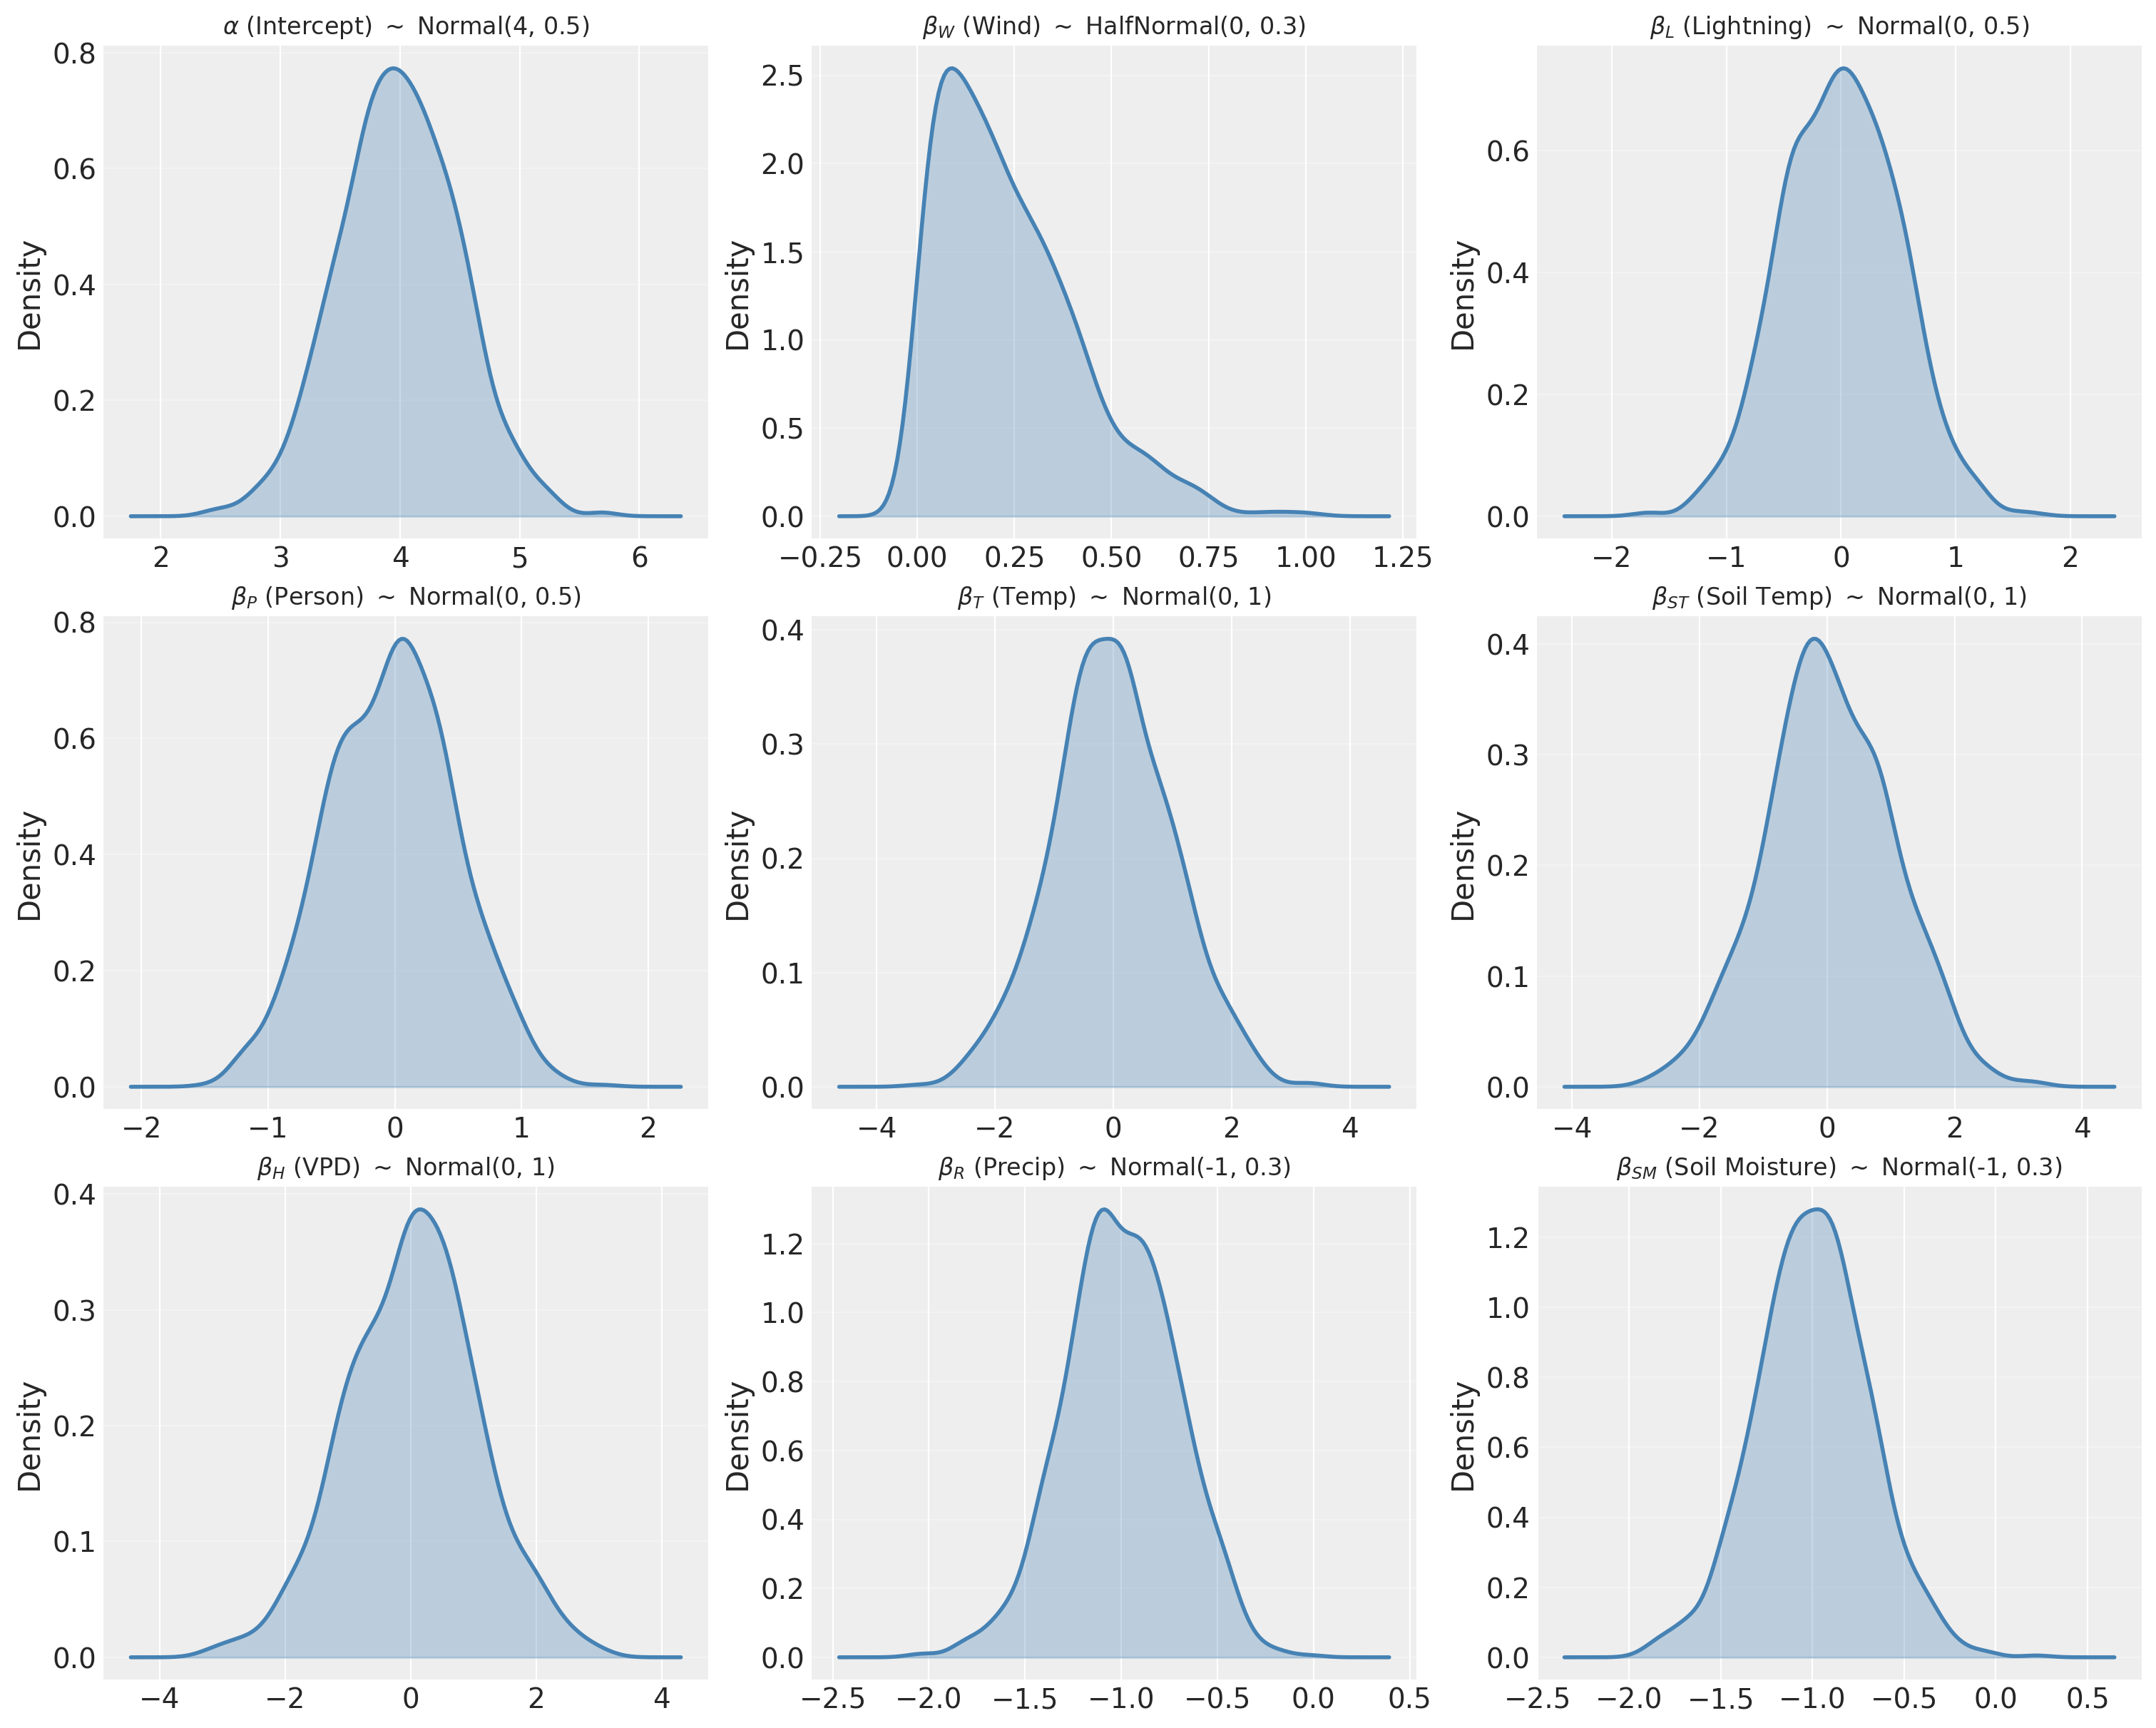

In [17]:
# Create a 3x3 grid for the 9 priors defined in the text
fig, axes = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True)
axes = axes.flatten()

# 1. Alpha (y-intercept)
alpha = stats.norm.rvs(loc=4, scale=0.5, size=N)
plot_density(alpha, axes[0], r"$\alpha$ (Intercept) $\sim$ Normal(4, 0.5)")

# 2. Beta_W (Wind Speed)
beta_w = stats.halfnorm.rvs(loc=0, scale=0.3, size=N)
plot_density(beta_w, axes[1], r"$\beta_W$ (Wind) $\sim$ HalfNormal(0, 0.3)")

# 3. Beta_L (Lightning)
beta_l = stats.norm.rvs(loc=0, scale=0.5, size=N)
plot_density(beta_l, axes[2], r"$\beta_L$ (Lightning) $\sim$ Normal(0, 0.5)")

# 4. Beta_P (Person)
beta_p = stats.norm.rvs(loc=0, scale=0.5, size=N)
plot_density(beta_p, axes[3], r"$\beta_P$ (Person) $\sim$ Normal(0, 0.5)")

# 5. Beta_T (Temperature)
beta_t = stats.norm.rvs(loc=0, scale=1, size=N)
plot_density(beta_t, axes[4], r"$\beta_T$ (Temp) $\sim$ Normal(0, 1)")

# 6. Beta_ST (Soil Temperature)
beta_st = stats.norm.rvs(loc=0, scale=1, size=N)
plot_density(beta_st, axes[5], r"$\beta_{ST}$ (Soil Temp) $\sim$ Normal(0, 1)")

# 7. Beta_H (VPD)
beta_h = stats.norm.rvs(loc=0, scale=1, size=N)
plot_density(beta_h, axes[6], r"$\beta_H$ (VPD) $\sim$ Normal(0, 1)")

# 8. Beta_R (Precipitation)
beta_r = stats.norm.rvs(loc=-1, scale=0.3, size=N)
plot_density(beta_r, axes[7], r"$\beta_R$ (Precip) $\sim$ Normal(-1, 0.3)")

# 9. Beta_SM (Soil Moisture)
beta_sm = stats.norm.rvs(loc=-1, scale=0.3, size=N)
plot_density(beta_sm, axes[8], r"$\beta_{SM}$ (Soil Moisture) $\sim$ Normal(-1, 0.3)")

With the prior predictive simulation, we’re asking ourselves the question: *Do the assumptions we've encoded in our priors actually produce plausible wildfire sizes, or have we inadvertently built something absurd?* It seems that the priors we’ve specified allow for a wide range of coefficient directions and magnitudes without forcing extreme predictions in either direction. Nothing here is alarming so we'll proceed to fitting our Bayesian Multiple Linear Regression model using [PyMC](https://www.pymc.io/welcome.html#example-from-linear-regression) and evaluating those results through our forest plot and posterior predictive plot:

In [18]:
# Adding the Categorical variables in the FIRE_CAUSE column as a predictor
large_fire_df["cause_id"] = pd.Categorical(large_fire_df["FIRE_CAUSE"]).codes

with pm.Model() as multi_linear_reg_model:
    a = pm.Normal("a", mu=4, sigma=0.5)
    ws = pm.HalfNormal("ws", sigma=0.3)
    c = pm.Normal("c", mu=0, sigma=0.5, shape=[large_fire_df["cause_id"].max() + 1])
    t = pm.Normal("t", mu=0, sigma=1)
    st = pm.Normal("st", mu=0, sigma=1)
    h = pm.Normal("h", mu=0, sigma=1)
    r = pm.Normal("r", mu=-1, sigma=0.3)
    sm = pm.Normal("sm", mu=-1, sigma=0.3)
    sigma = pm.HalfNormal("sigma", sigma=0.5)

    mu = pm.Deterministic(
        "mu",
        a + (ws * large_fire_df["wind_speed_log1ptransformed_std"].values) + (c[large_fire_df["cause_id"].values]) + (t * large_fire_df["temp_c_ign_date_std"].values) + (st * large_fire_df["soil_temp_c_lvl1_ign_date_std"].values) + (h * large_fire_df["monthly_mean_humidity_vpd_kPa_std"].values) + (r * large_fire_df["monthly_total_precip_mm_std"].values) + (sm * large_fire_df["monthly_mean_soil_moisture_mm_std"].values)
      )

    size_logTransform = pm.Normal("size", mu=mu, sigma=sigma, observed=large_fire_df[target_col])
    multiple_linear_regression_model_trace = pm.sample(1000, tune=1000, random_seed=RANDOM_SEED)

Output()

In [19]:
az.summary(multiple_linear_regression_model_trace, kind="stats")

,mean,sd,hdi_5.5%,hdi_94.5%
a,5.644,0.256,5.224,6.036
c[0],0.985,0.257,0.573,1.383
c[1],0.338,0.257,-0.076,0.748
c[2],0.335,0.263,-0.088,0.745
h,0.119,0.031,0.073,0.172
...,...,...,...,...
sigma,1.435,0.016,1.410,1.462
sm,0.044,0.027,0.004,0.089
st,0.102,0.068,-0.008,0.203
t,-0.069,0.065,-0.175,0.030


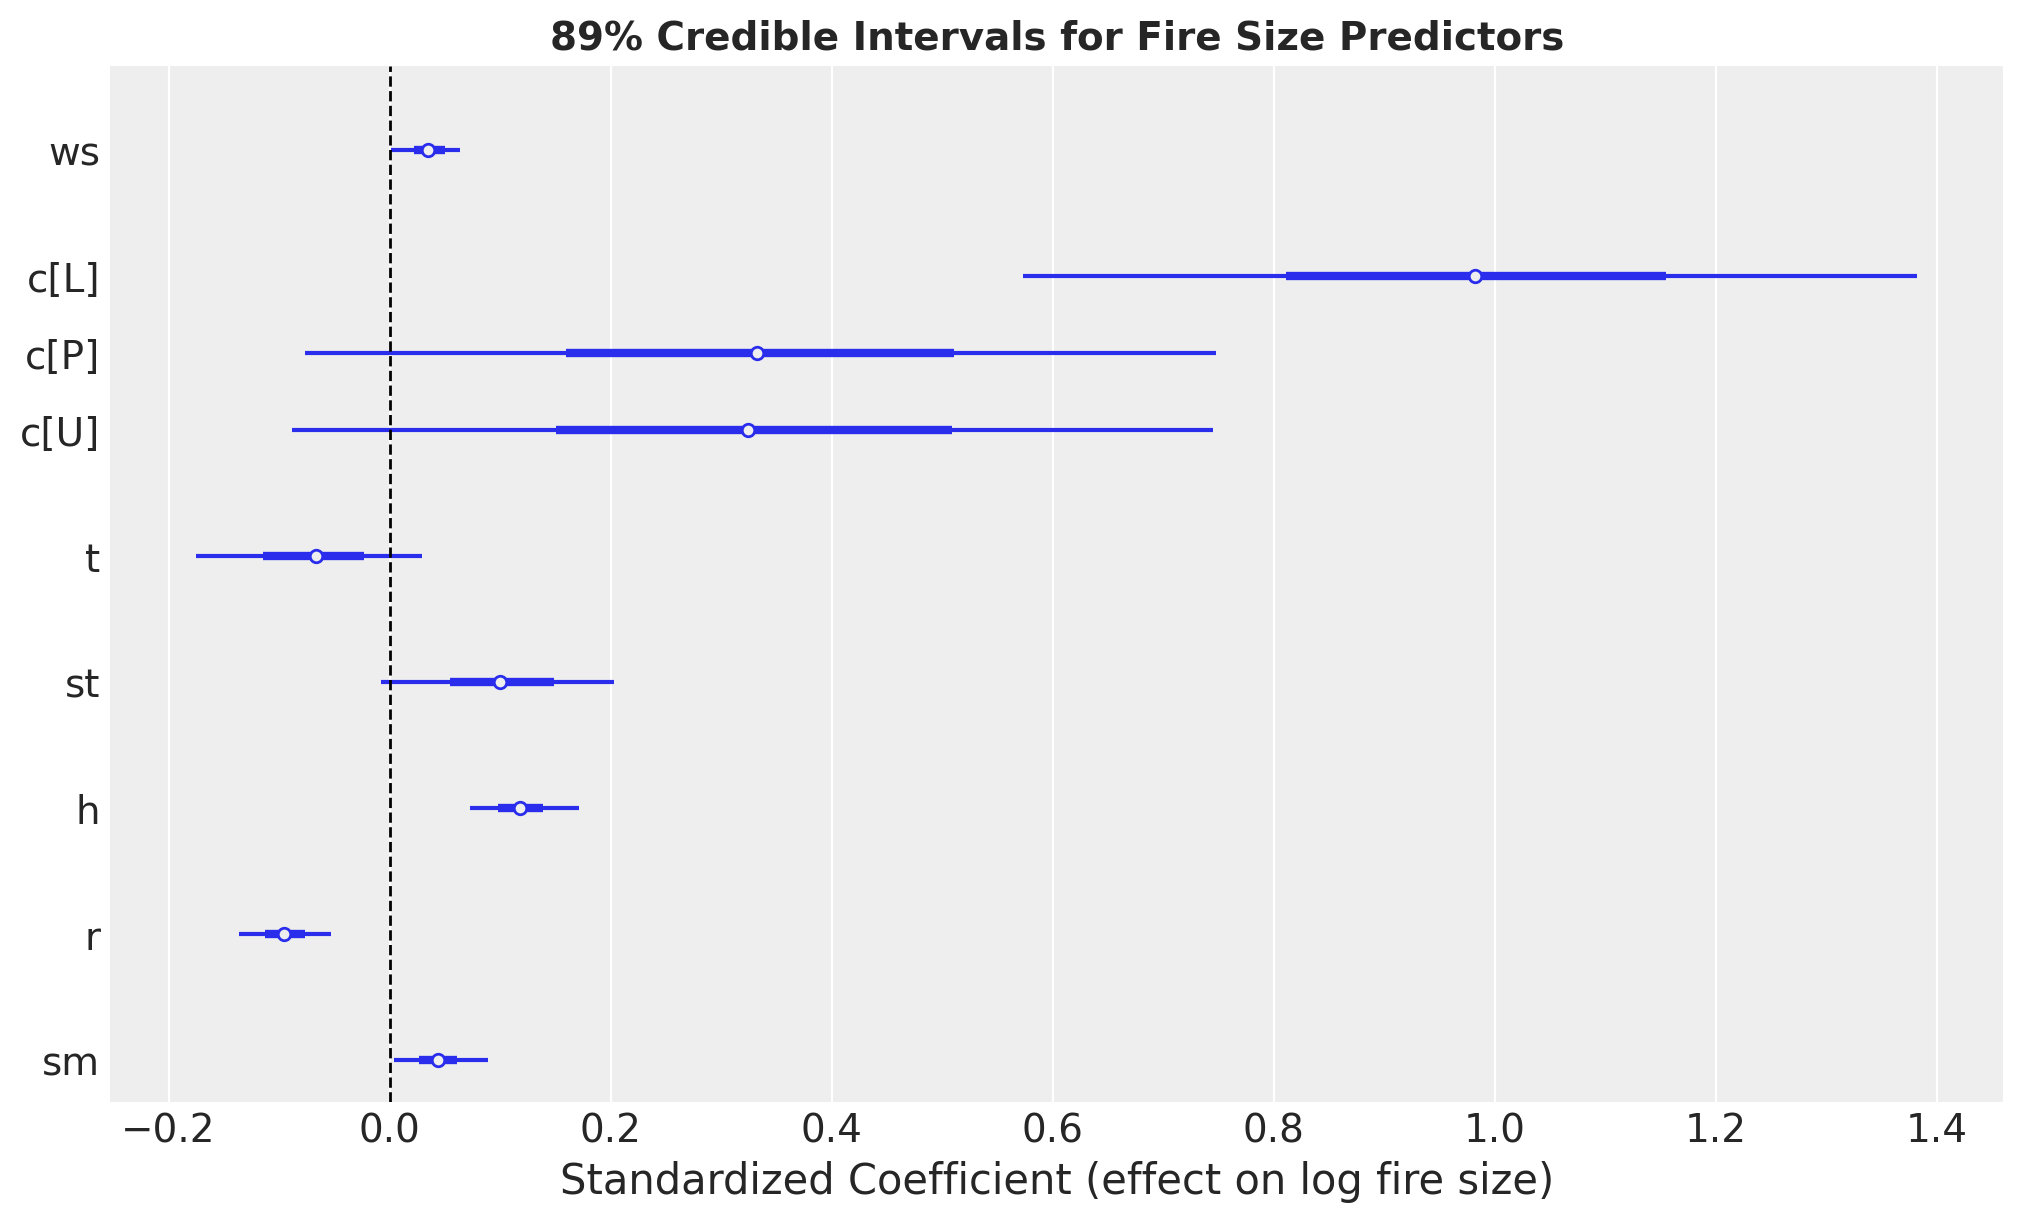

In [20]:
# What actually matters for your research question
variables = ["ws", "c", "t", "st", "h", "r", "sm"]

ax_arr = az.plot_forest(
    multiple_linear_regression_model_trace,
    var_names=variables,
    combined=True,
    hdi_prob=0.89,
    figsize=(10, 6)
)
ax = ax_arr[0]

plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('89% Credible Intervals for Fire Size Predictors', fontsize=14, fontweight='bold')
plt.xlabel('Standardized Coefficient (effect on log fire size)')

##############################################################
### OPTIONAL: Get current labels and replace the c indices ###
##############################################################
labels = [item.get_text() for item in ax.get_yticklabels()]
new_labels = [
    label.replace("c[0]", "c[L]")
         .replace("[1]", "c[P]")
         .replace("[2]", "c[U]")
    for label in labels
]
ax.set_yticklabels(new_labels)
##############################################################
##############################################################

plt.show()

So, what do the results of our Bayesian regression model tell us about its ability to predict large fires using only predictor variables? Well there’s a few key observations about our **forest plot** that are noteworthy.

The first one that stands out is how strong our `FIRE_CAUSE` dummy variables are as a predictor, especially lightning where its entire 89% credible interval is centred near 1.0 making it our strongest predictor. The data is pretty unambiguous here but if we consider the wider ramifications for this finding, we would hazard a strong guess that there are a lot of confounding variables that’s responsible for driving this result that we can’t currently quantify with our data. One hypothesis for why lightning might be strongly associated with large fires is because when it strikes in remote areas and starts a wildfire, it’s not as easy to detect since there’s little to no human observers. So by the time the lightning-caused wildfire is finally detected, it might have already grown to a size that exceeds our 100 hectare limit for this analysis. As a result, other potential variables that might be useful in quantifying the “remoteness” of a fire and potentially influencing the lightning’s predictive effect would be the wildfire’s ignition distance from the nearest highway, firehall, or population centre.

What’s also interesting here is how much wider the credible intervals are for the `FIRE_CAUSE` dummy variables as opposed to the other atmospheric variables, signalling the model’s uncertainty towards these sets of predictors. However, this shouldn’t come as a surprise given the `FIRE_CAUSE` data was split into 3 categories, meaning the model didn’t have as much data to work with in order to be confident in its predictive effects as opposed to the other atmospheric predictors. Based on our `value_counts()` method, lightning-caused fires were responsible for 58% of large fires in our dataset while people were the other significant cause at 36% of recorded causes.

In [21]:
counts = large_fire_df["FIRE_CAUSE"].value_counts()
proportions = large_fire_df["FIRE_CAUSE"].value_counts(normalize=True).mul(100).round(2)

print(pd.concat([counts, proportions], axis=1, keys=["Count", "Percentage (%)"]))

            Count  Percentage (%)
FIRE_CAUSE                       
Lightning    2213           57.96
Person       1369           35.86
Unknown       236            6.18


Another noteworthy result is that even though we set the prior distributions for rain and soil moisture to centre around a -1 standard deviation, the data was clear in that their effect on large fires was inconsequential given how their interval shifted to centre around 0. This is an example of a dataset having the capability to wash out the priors due to its sheer size. It’s also direct evidence that one of these variables don’t carry a strong independent signal once other predictors are included.

The last result worth flagging that seems completely counterintuitive was temperature's slightly negative posterior, sitting just below zero. Our original DAG hypothesized a positive relationship between temperature and fire size, so this runs against expectation since intuition leads us to believe that hotter conditions should promote larger fires. Rather than a genuine negative causal effect, this is more likely a symptom of multicollinearity where temperature and soil temperature may be so strongly correlated in our dataset that their individual contributions then become difficult to disentangle. In a sense, soil temperature is borrowing the explanatory signal that belongs to temperature which suppresses its coefficient and potentially inverting its sign. This is precisely the kind of distortion that a well-specified causal DAG is designed to flag.

In [22]:
with multi_linear_reg_model:
    multi_linear_reg_ppc = pm.sample_posterior_predictive(multiple_linear_regression_model_trace, var_names=["mu", "size"])


mu_mean = multi_linear_reg_ppc.posterior_predictive["mu"].mean(dim=["chain", "draw"])
mu_PI = az.hdi(multi_linear_reg_ppc.posterior_predictive["mu"], 0.89)

D_sim = multi_linear_reg_ppc.posterior_predictive["size"].mean(dim=["chain", "draw"])
D_PI = az.hdi(multi_linear_reg_ppc.posterior_predictive["size"], 0.89)

Output()

/tmp/ipykernel_4395/3558475919.py:2: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "C0o" (-> marker='o'). The keyword argument will take precedence.
  plt.errorbar(


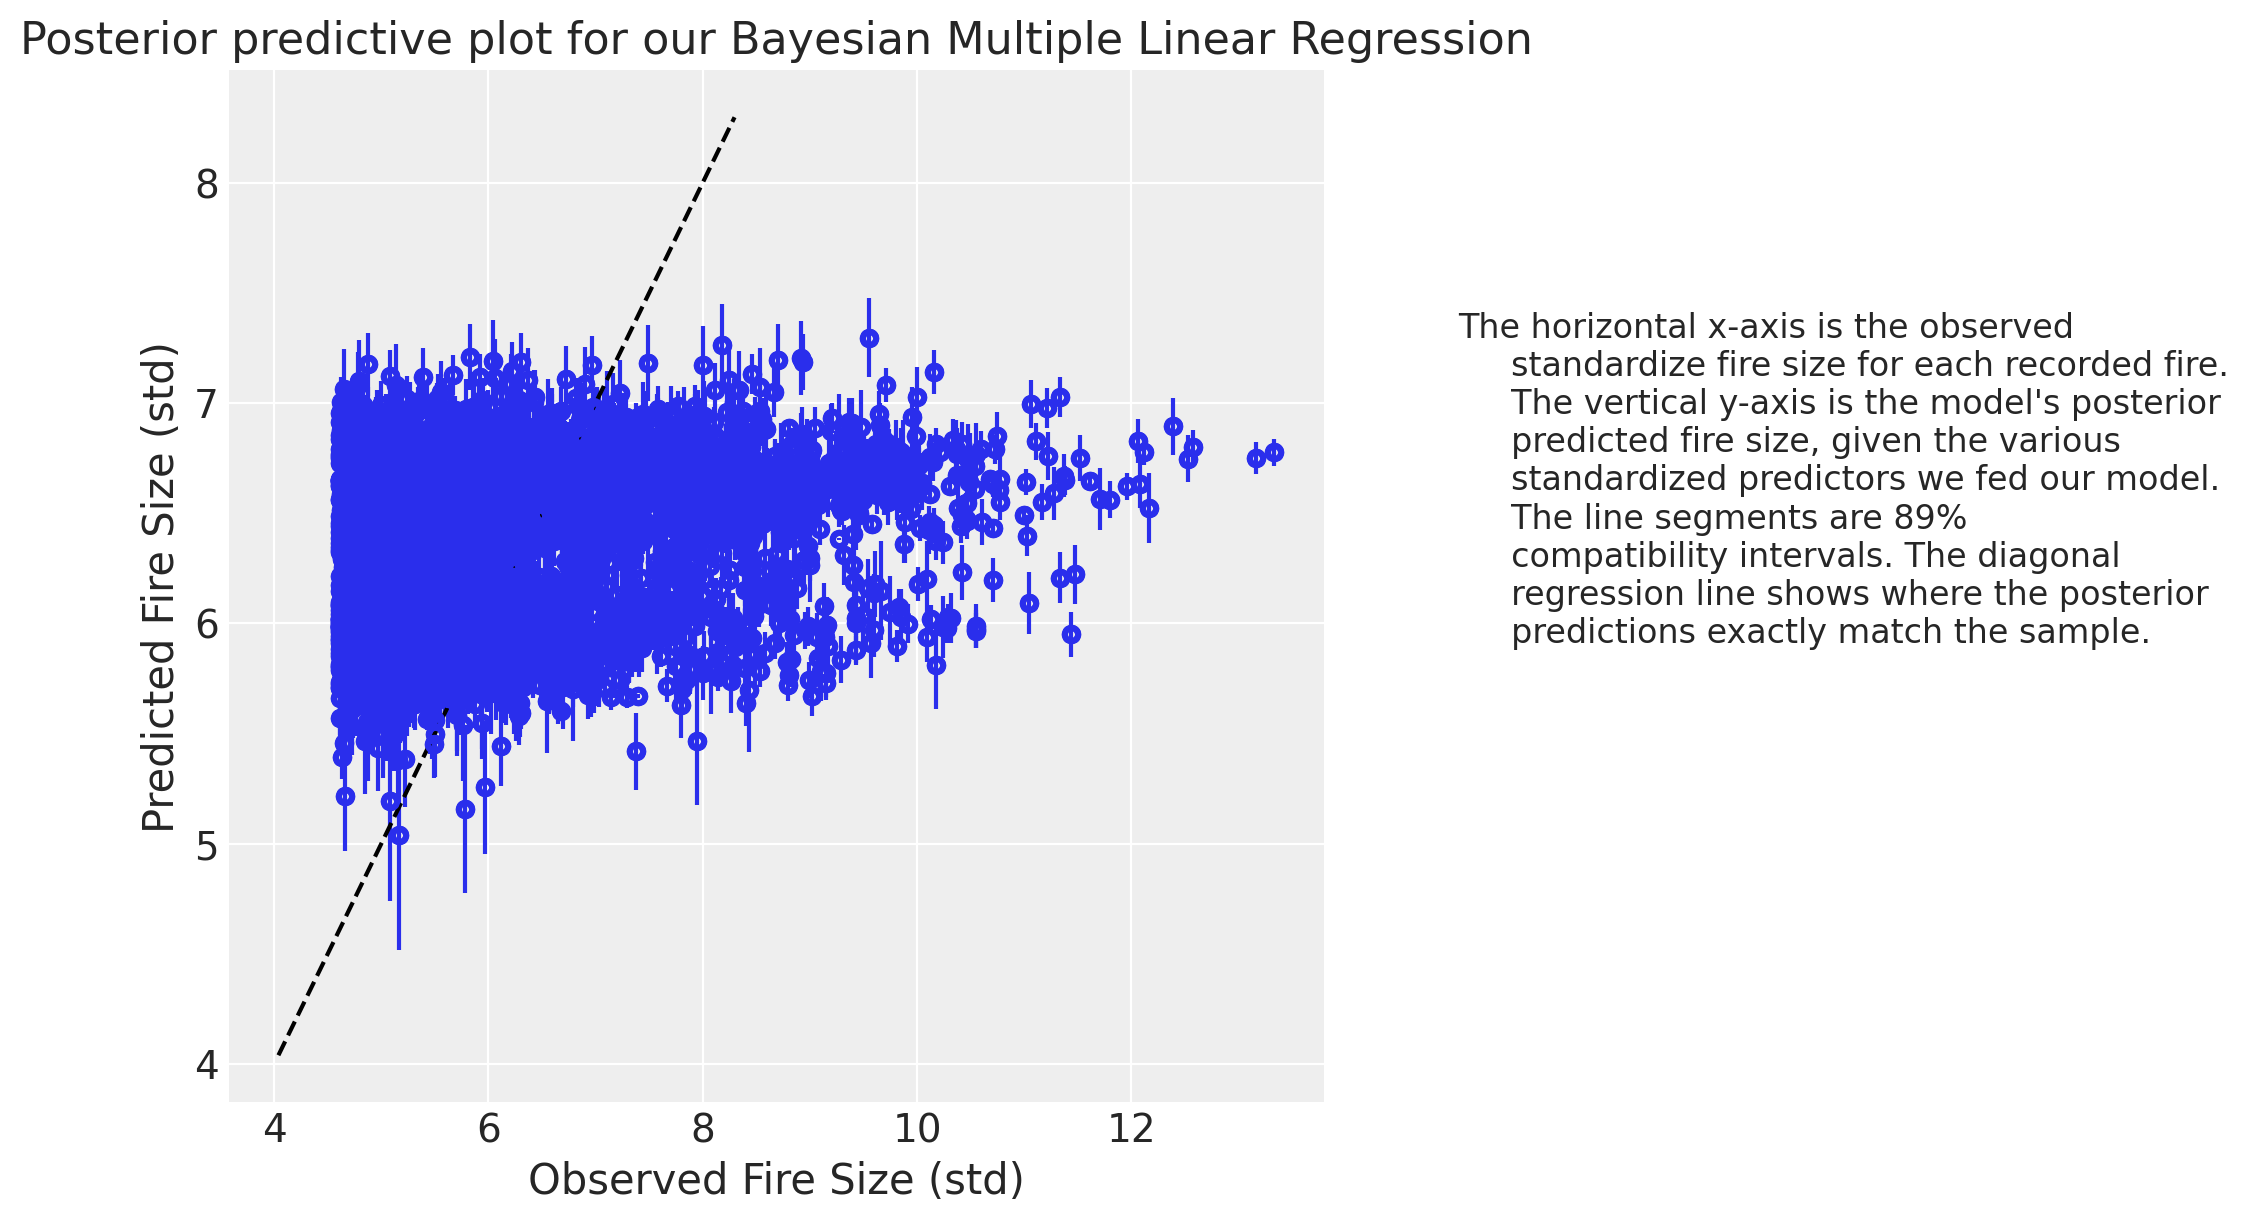

In [23]:
fig, ax = plt.subplots(figsize=(6, 6))
plt.errorbar(
    large_fire_df[target_col].values,
    D_sim,
    yerr=np.abs(np.array(D_sim) - mu_PI.min(dim="hdi").to_array()),
    fmt="C0o",
    marker="$\\circ$"
)
ax.scatter(
    large_fire_df[target_col].values,
    D_sim,
    marker="$\\circ$"
  )

min_x, max_x = D_sim.min()-1, D_sim.max()+1
ax.plot([min_x, max_x], [min_x, max_x], "k--")
plt.suptitle(
    x=1.43,
    y=0.75,
    t="The horizontal x-axis is the observed \n \
    standardize fire size for each recorded fire. \n \
    The vertical y-axis is the model's posterior \n \
    predicted fire size, given the various \n \
    standardized predictors we fed our model. \n \
    The line segments are 89% \n \
    compatibility intervals. The diagonal \n \
    regression line shows where the posterior \n \
    predictions exactly match the sample.",
    ma="left"
  )
ax.set_ylabel("Predicted Fire Size (std)")
ax.set_xlabel("Observed Fire Size (std)")
ax.set_title("Posterior predictive plot for our Bayesian Multiple Linear Regression");

Moving over to our **posterior predictive plot**, unfortunately this graph is telling us something concerning: Our model is severely underfitting! Reality tells us that the majority of fires fall within a standardized value of about 5 to 11 but the model regularly predicts a much tighter band between 5.5 to 7 which means it captures the central tendencies of fire size but fails at the extremes. The black dotted line in the plot represents instances where our model perfectly predicted the size of the fire. Unfortunately, its predictions were nowhere near the black dotted line aside from the predictions that fell within the middle of the distribution. It's essentially predicting near the mean for almost every observed fire.

To summarize, the atmospheric predictors in the Bayesian Multiple Linear Regression model seem to be weak predictors of fire size across the board given their proximity to 0 with tight credible intervals. The practical interpretation here is that atmospheric conditions at ignition (such as wind speed or temperature), or even those measured at a monthly or daily resolution may simply not be the primary drivers of fires that grow to 100, or even 10,000 hectares. Fire size at that scale is probably dominated by factors we haven't included in our data yet such as suppression response time, terrain/slope, fuel load/type, fire weather during the burn (not just at ignition), and proximity to suppression resources. While not the results we were looking for in terms of predictive accuracy, these results still provide us value in strengthening our causal understanding of atmospheric predictors on wildfire size and sets up our first set of hypotheses to pressure-test with a frequentist lens.

## **Where Frequentist Inference holds the line**

In the previous section, our Bayesian model played a meaningful role in helping us extract key causal insight from our data. Let’s recap what we learned from our Bayesian model: Lightning dominates as a predictor, soil moisture's signal collapses once other predictors are included, and that our atmospheric predictors across the board only explained a modest slice of what drives large fire growth. However even with all the value that our Bayesian model gave us, its uncertainty quantification through its credible intervals also has its limits on the insights it can reveal. For example, our Bayesian model can’t tell us how much variance our predictors can collectively explain or whether those relationships hold consistently across BC's geographically diverse fire zones. This is an area where **Frequentist Inference** may be able to help us here fill the gap.

Before we fit anything, let’s do one more diagnostic check to investigate multicollinearity by building a **correlation matrix**. The reason being is that several of our predictors, such as temperature, soil temperature, VPD, and soil moisture, may be measuring related atmospheric phenomena which will undoubtedly share a fair amount of variance. If two predictors are highly correlated with each other, the model can't cleanly attribute the causal effects to either one which inflates its uncertainty about its predictions. Given we're here to interrogate a causal DAG rather than just minimize prediction error, this correlational effect matters more than it would in a pure forecasting context.

Here's the correlation matrix across our continuous predictors:

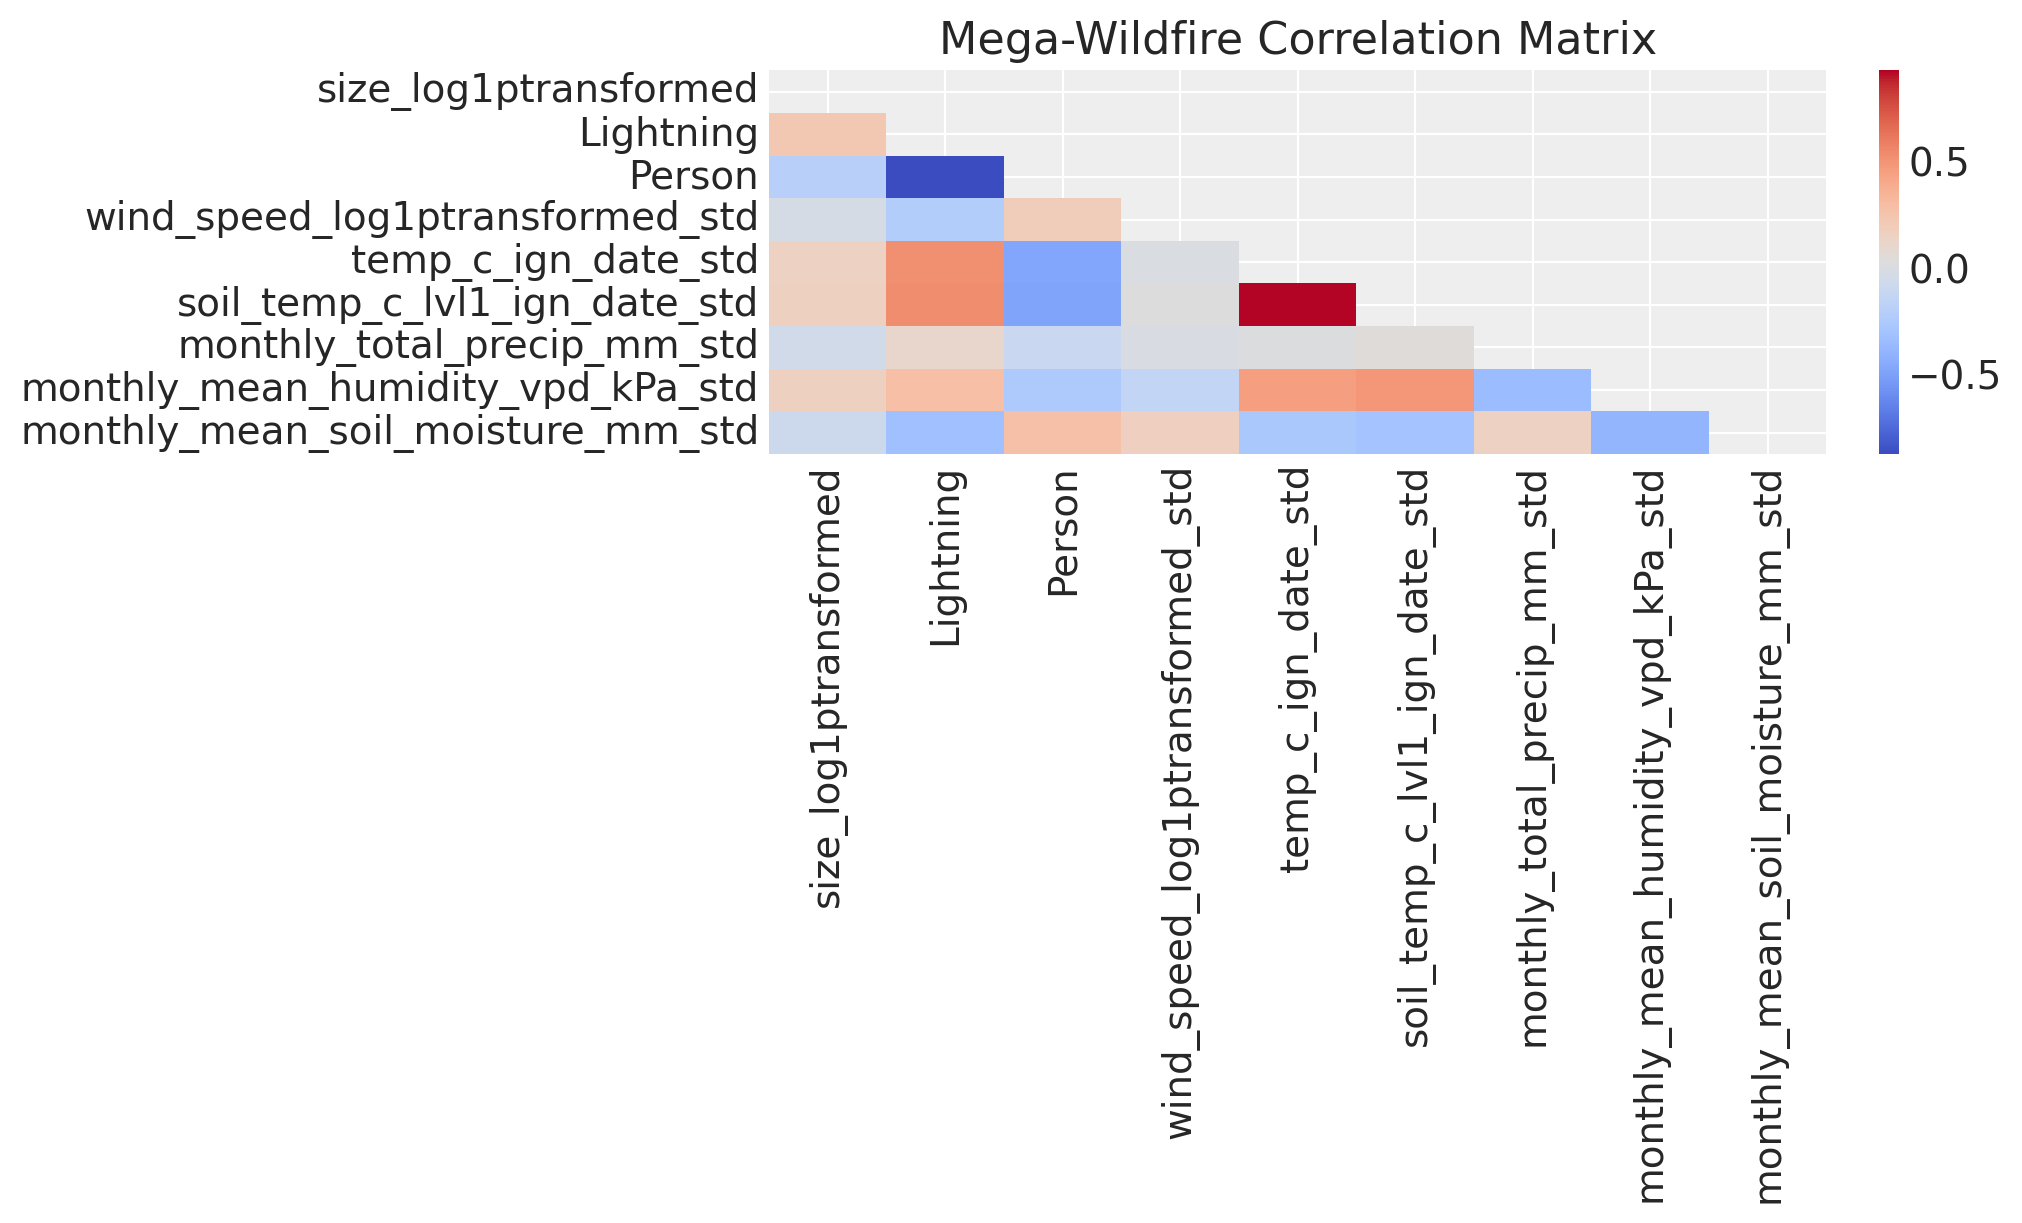

In [24]:
# Multicollinearity check
wildfire_corr = large_fire_df[
    [
        "size_log1ptransformed",
        "Lightning",
        "Person",
        "wind_speed_log1ptransformed_std",
        "temp_c_ign_date_std",
        "soil_temp_c_lvl1_ign_date_std",
        "monthly_total_precip_mm_std",
        "monthly_mean_humidity_vpd_kPa_std",
        "monthly_mean_soil_moisture_mm_std"
    ]
].corr()

trimask = np.triu(np.ones_like(wildfire_corr, dtype=bool))

plt.figure(figsize=(10,6))
sns.heatmap(wildfire_corr, cmap='coolwarm', mask=trimask)
plt.title("Mega-Wildfire Correlation Matrix")
plt.show()

From our correlation matrix, the insight that screams at us here is how strongly correlated temperature is to soil temperature. This is yet another data point that one of these variables (likely soil temperature) will have a mediating effect on the other one making their individual predictor estimates less reliable. We already saw the symptoms in the Bayesian model where temperature’s posterior returned a completely unexpected result.

One quick note on terminology. In machine learning, the term ***weight*** is generally preferred over ***coefficient***, which is more common in traditional statistics. In the context of frequentist models, the two terms are interchangeable as both refer to a *single fixed value*, or **point estimate**, that quantifies the effect of a predictor on the model's output. In the Bayesian modelling section, we used coefficient or parameter instead because each parameter was represented not as a single point estimate, but as a full posterior *distribution of plausible values*. Going forward, we'll use *weight* throughout to stay consistent with standard machine learning and frequentist terminology that this section focuses on.

Let’s now turn our attention to modelling by fitting a **Frequentist OLS Multiple Linear Regression** model to the entire dataset using [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) and establishing a baseline of our model’s ability to explain the data’s variance.

In [25]:
# Separate your predictors
continuous_cols = ["wind_speed_log1ptransformed", "temp_c_ign_date", "soil_temp_c_lvl1_ign_date", "monthly_total_precip_mm", "monthly_mean_humidity_vpd_kPa", "monthly_mean_soil_moisture_mm"]
dummy_cols      = ["Lightning", "Person"]
predictor_cols_unstd = continuous_cols + dummy_cols

# Standardize only the continuous predictors
scaler = StandardScaler()
continuous_scaled = scaler.fit_transform(large_fire_df[continuous_cols])

# Combine scaled continuous + untouched dummies
X = pd.DataFrame(
      np.hstack([
      continuous_scaled,
      large_fire_df[dummy_cols].values
    ]),
      columns=predictor_cols_unstd
)

y = large_fire_df.loc[large_fire_df[dummy_cols].index, "size_log1ptransformed"]

In [26]:
baseline_multiLinear_regression = LinearRegression()
baseline_multiLinear_regression.fit(X, y)
baseline_y_pred = baseline_multiLinear_regression.predict(X)

# Check combined R²
r2_combined = r2_score(y, baseline_y_pred)
print(f"Combined R² = {r2_combined:.3f} \n")

# Check coefficients (are they in expected directions?)
print("Individual Regression Coefficients (Scaled): \n")
for i, col in enumerate(X.columns):
    print(f"{col}: β = {baseline_multiLinear_regression.coef_[i]:.4f}")

Combined R² = 0.067 

Individual Regression Coefficients (Scaled): 

wind_speed_log1ptransformed: β = 0.0317
temp_c_ign_date: β = -0.0677
soil_temp_c_lvl1_ign_date: β = 0.0993
monthly_total_precip_mm: β = -0.0888
monthly_mean_humidity_vpd_kPa: β = 0.1244
monthly_mean_soil_moisture_mm: β = 0.0526
Lightning: β = 0.6412
Person: β = -0.0081


From the low R2 score, it seems that our Frequentist model was only able to explain about 6.7% of the variance in large fires. However we should have expected this already given the underfitting we saw in our Bayesian model’s posterior predictive plot or the close proximity to 0 that each of our weights displayed in the forest plot. After fitting both Frequentist and Bayesian flavours of Linear Regression, it’s becoming quite apparent that this model is structurally not the best fit to explain the variance in our dataset. So is there any more juice left to squeeze or should we abandon linear regression models completely?

Well if we think about the underlying **data generating process** (remember that term from [part 1](https://medium.com/towards-artificial-intelligence/rethinking-predictors-why-causal-reasoning-matters-in-data-science-part-1-f1d4c1e08068)?) of our data, we must remember that we’re examining the wildfire conditions of a massive province of British Columbia filled with diverse climates and geography. Maybe there’s a way to examine subsections of our dataset to see if there are large differences between regions? Fortunately, our dataset includes a variable called `FRCNTR` that indicates which “fire centre” did the wildfire burn in. These fire centres are administrative zones created by the BC Wildfire Service for the purpose of delegating wildfire management responsibilities across the province’s diverse region. Perhaps these splits contain some information about the similarity in geography or climate? Let’s see what happens if we split the data across different fire centres and fit a regression model to each subsection:

In [27]:
def fit_zone_models_with_metrics(df, continuous_cols, dummy_cols, target_col='SIZE_HA', zone_col='FRCNTR'):
    """
    Fit separate linear regression models for each fire zone with comprehensive metrics.

    Parameters
    ----------
    df : pd.DataFrame
        Dataframe with fire data
    continuous_cols : list
        List of predictor column names
    dummy_cols : list
        List of dummy column names
    target_col : str
        Target variable column name
    zone_col : str
        Zone identifier column name

    Returns
    -------
    results_df : pd.DataFrame
        Summary statistics per zone as well as the standardized weights
    all_predictions : pd.DataFrame
        All predictions for pooled R² calculation
    """

    zones = df[zone_col].unique()
    zones = sorted([z for z in zones if pd.notna(z)])  # Remove NaN zones
    predictor_cols_unstd = continuous_cols + dummy_cols

    results_list = []
    predictions_list = []
    coefficients_list = []

    print("="*80)
    print("FIRE ZONE REGRESSION ANALYSIS")
    print("="*80)

    for zone in zones:
        zone_df = df[df[zone_col] == zone].copy()

        # Drop rows with missing predictors or target
        zone_df = zone_df[predictor_cols_unstd + [target_col]].dropna()

        n_samples = len(zone_df)

        print(f"\n{'─'*80}")
        print(f"FIRE ZONE {zone} | n = {n_samples}")
        print(f"{'─'*80}")

        if n_samples < 10:  # Skip zones with too few samples
            print(f"⚠️  Skipping - insufficient data (n < 10)")
            continue

        # # Separate features and target
        # X = standardize(zone_df[predictor_cols].values)
        # y = standardize(zone_df[target_col].values)

        # Standardize only the continuous predictors
        scaler = StandardScaler()
        continuous_scaled = scaler.fit_transform(zone_df[continuous_cols])

        # Combine scaled continuous + untouched dummies
        X = pd.DataFrame(
              np.hstack([
              continuous_scaled,
              zone_df[dummy_cols].values
            ]),
              columns=predictor_cols_unstd
        )

        y = zone_df.loc[zone_df[dummy_cols].index, target_col]

        # Fit model
        model = LinearRegression()
        model.fit(X, y)
        y_pred = model.predict(X)

        # Calculate metrics
        r2 = r2_score(y, y_pred)
        rmse = np.sqrt(mean_squared_error(y, y_pred))

        # Store results
        results_list.append({
            'zone': zone,
            'n_samples': n_samples,
            'r2_score': r2,
            'rmse': rmse,
            'mean_fire_size': y.mean(),
            'std_fire_size': y.std()
        })

        # Store predictions for pooled R²
        predictions_list.append(pd.DataFrame({
            'zone': zone,
            'y_true': y,
            'y_pred': y_pred
        }))

        # Store standardized weights
        coef_dict = {'zone': zone}
        for i, col in enumerate(predictor_cols_unstd):
            coef_dict[col] = model.coef_[i]
        coefficients_list.append(coef_dict)

        # Print zone-specific results
        print(f"\n📊 Model Performance:")
        print(f"   R² Score:  {r2:.4f}")
        print(f"   RMSE:      {rmse:.2f} hectares")

        print(f"\n📈 Standardized Weights (effect of 1 SD increase):")
        for i, col in enumerate(predictor_cols_unstd):
            coef = model.coef_[i]
            direction = "↑" if coef > 0 else "↓"
            print(f"   {col:35s}: {coef:>8.4f} {direction}")

    # Convert to DataFrames
    results_df = pd.DataFrame(results_list)
    all_predictions = pd.concat(predictions_list, ignore_index=True)
    coefficients_df = pd.DataFrame(coefficients_list)

    # ═══════════════════════════════════════════════════════════════════════
    # AGGREGATE METRICS
    # ═══════════════════════════════════════════════════════════════════════

    print("\n" + "="*80)
    print("AGGREGATE METRICS ACROSS ALL ZONES")
    print("="*80)

    # 1. Weighted R² (weighted by sample size)
    total_samples = results_df['n_samples'].sum()
    weighted_r2 = (results_df['r2_score'] * results_df['n_samples']).sum() / total_samples

    # 2. Overall R² from pooled predictions
    pooled_r2 = r2_score(all_predictions['y_true'], all_predictions['y_pred'])

    # 3. R² statistics
    r2_mean = results_df['r2_score'].mean()
    r2_median = results_df['r2_score'].median()
    r2_min = results_df['r2_score'].min()
    r2_max = results_df['r2_score'].max()
    r2_std = results_df['r2_score'].std()

    print(f"\n📊 R² Score Summary:")
    print(f"   Weighted R² (by zone size):     {weighted_r2:.4f}")
    print(f"   Pooled R² (all predictions):    {pooled_r2:.4f}")
    print(f"   Mean R² across zones:           {r2_mean:.4f} ± {r2_std:.4f}")
    print(f"   Median R²:                      {r2_median:.4f}")
    print(f"   Range:                          [{r2_min:.4f}, {r2_max:.4f}]")

    print(f"\n📈 Sample Distribution:")
    print(f"   Total observations:             {total_samples:,}")
    print(f"   Number of zones modeled:        {len(results_df)}")
    print(f"   Avg samples per zone:           {total_samples/len(results_df):.0f}")

    # 4. Weights consistency across zones
    print(f"\n🔍 Predictor Weight Statistics (Standardized):")
    print(f"   {'Predictor':<35s} {'Mean β':<10s} {'Std Dev':<10s} {'Sign Consistency'}")
    print(f"   {'-'*75}")

    for col in predictor_cols_unstd:
        coef_values = coefficients_df[col].values
        mean_coef = coef_values.mean()
        std_coef = coef_values.std()

        # Sign consistency: what % of zones have same sign as mean?
        if mean_coef != 0:
            same_sign_pct = (np.sign(coef_values) == np.sign(mean_coef)).mean() * 100
        else:
            same_sign_pct = 50.0

        print(f"   {col:<35s} {mean_coef:>8.4f}   {std_coef:>8.4f}   {same_sign_pct:>5.1f}%")

    print("\n" + "="*80 + "\n")

    # Concatenating Results with Weights:
    results_df = pd.merge(results_df, coefficients_df, on="zone", how="inner")

    return results_df, all_predictions

In [28]:
def plot_zone_model_results(
    results_df,
    predictor_cols,
    zone_col="zone",
    r2_col="r2_score",
    n_samples_col="n_samples",
):
    """
    Plots R² scores by fire zone and a heatmap of standardized coefficients.

    Parameters
    ----------
    results_df : pd.DataFrame
        DataFrame containing model results with columns for zone, R² score,
        sample size, and one column per predictor with its standardized coefficient.
    predictor_cols : list[str]
        Names of the predictor columns to include in the heatmap.
    zone_col : str, optional
        Column name for the fire zone identifier. Default is 'zone'.
    r2_col : str, optional
        Column name for the R² score. Default is 'r2_score'.
    n_samples_col : str, optional
        Column name for the number of samples. Default is 'n_samples'.
    """
    # ── 1. R² by zone + sample-size scatter ──────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: horizontal bar chart of R² scores, sorted by zone
    results_sorted = results_df.sort_values(zone_col, ascending=False)
    ax1 = axes[0]
    ax1.barh(
        results_sorted[zone_col].astype(str),
        results_sorted[r2_col],
        color="steelblue",
        edgecolor="black",
    )
    mean_r2 = results_df[r2_col].mean()
    ax1.axvline(
        mean_r2,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Mean R² = {mean_r2:.3f}",
    )
    ax1.set_xlabel("R² Score", fontsize=12)
    ax1.set_ylabel("Fire Centre", fontsize=12)
    ax1.set_title("R² Score by Fire Centre", fontsize=14, fontweight="bold")
    ax1.legend(loc="upper right", fontsize="small")
    ax1.grid(axis="x", alpha=0.3)

    # Right: scatter of sample size vs R²
    ax2 = axes[1]
    ax2.scatter(
        results_df[n_samples_col],
        results_df[r2_col],
        s=100,
        alpha=0.6,
        edgecolor="black",
        color="coral",
    )
    ax2.set_xlabel("Sample Size (n)", fontsize=12)
    ax2.set_ylabel("R² Score", fontsize=12)
    ax2.set_title("Model Performance vs Sample Size", fontsize=14, fontweight="bold")
    ax2.grid(alpha=0.3)

    for _, row in results_df.iterrows():
        ax2.annotate(
            int(row[zone_col]),
            (row[n_samples_col], row[r2_col]),
            fontsize=9,
            ha="center",
        )

    plt.tight_layout()
    plt.show()

    # ── 2. Heatmap of standardized weights ───────────────────────────────
    coef_matrix = (
        results_df[[zone_col] + predictor_cols]
        .set_index(zone_col)[predictor_cols]
        .T
    )

    plt.figure(figsize=(10, 6), layout="tight")
    sns.heatmap(
        coef_matrix,
        annot=True,
        fmt=".3f",
        cmap="RdBu_r",
        center=0,
        cbar_kws={"label": "Standardized Weights"},
        linewidths=0.5,
        linecolor="gray",
    )
    plt.title(
        "Standardized Weights Across Fire Centres",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )
    plt.xlabel("Fire Centre", fontsize=12)
    plt.ylabel("Predictor Variable", fontsize=12)
    plt.show()

In [29]:
# ═══════════════════════════════════════════════════════════════════════
# RUN ANALYSIS
# ═══════════════════════════════════════════════════════════════════════

results_df, all_predictions = fit_zone_models_with_metrics(
    df=large_fire_df,
    continuous_cols=continuous_cols,
    dummy_cols=dummy_cols,
    target_col="size_log1ptransformed",
    zone_col="FRCNTR"
)

FIRE ZONE REGRESSION ANALYSIS

────────────────────────────────────────────────────────────────────────────────
FIRE ZONE 2.0 | n = 343
────────────────────────────────────────────────────────────────────────────────

📊 Model Performance:
   R² Score:  0.1042
   RMSE:      1.08 hectares

📈 Standardized Weights (effect of 1 SD increase):
   wind_speed_log1ptransformed        :   0.0137 ↑
   temp_c_ign_date                    :  -0.0902 ↓
   soil_temp_c_lvl1_ign_date          :   0.0077 ↑
   monthly_total_precip_mm            :  -0.0674 ↓
   monthly_mean_humidity_vpd_kPa      :   0.1856 ↑
   monthly_mean_soil_moisture_mm      :  -0.0094 ↓
   Lightning                          :   0.2059 ↑
   Person                             :  -0.2885 ↓

────────────────────────────────────────────────────────────────────────────────
FIRE ZONE 3.0 | n = 406
────────────────────────────────────────────────────────────────────────────────

📊 Model Performance:
   R² Score:  0.1333
   RMSE:      1.59 hect

/tmp/ipykernel_4395/639628470.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


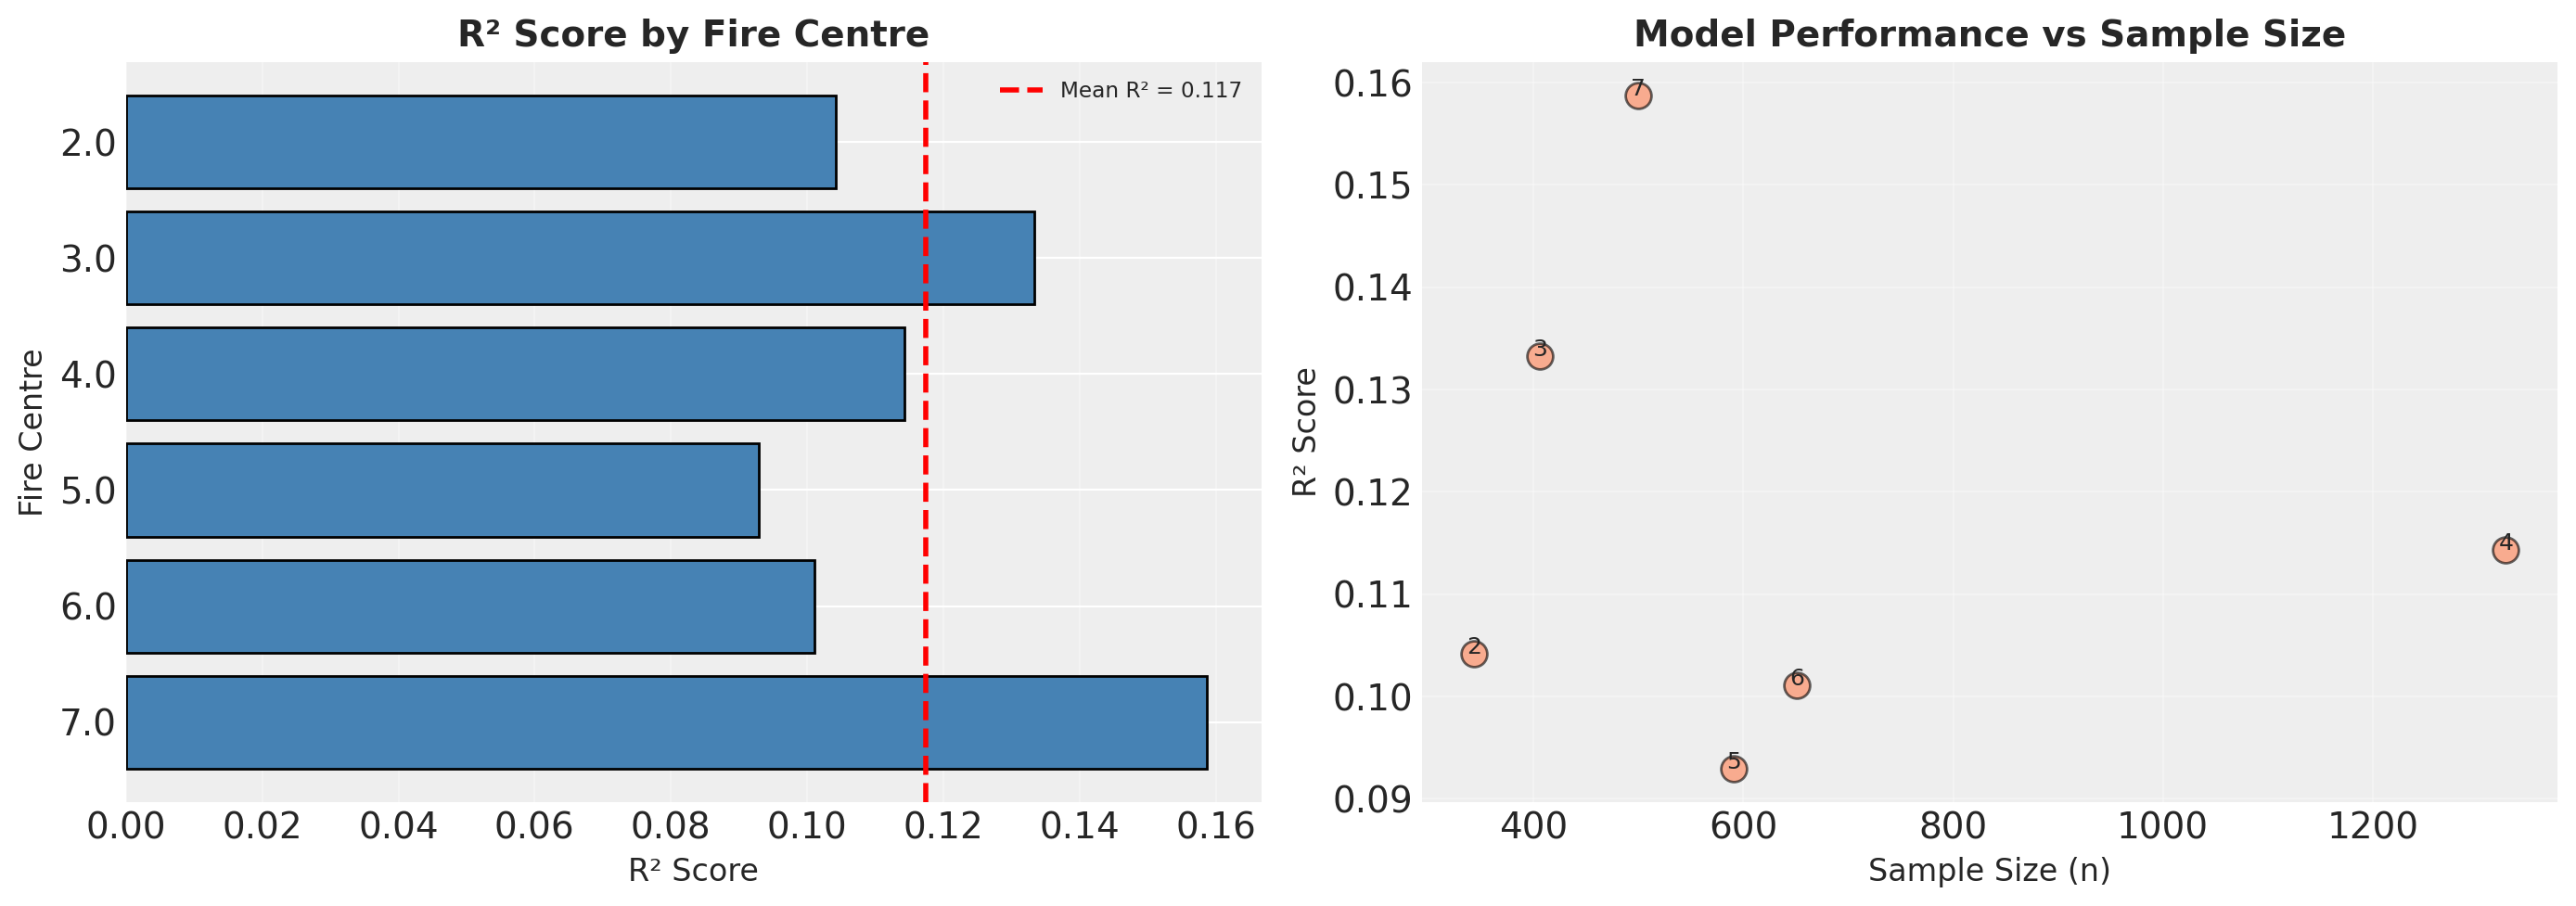

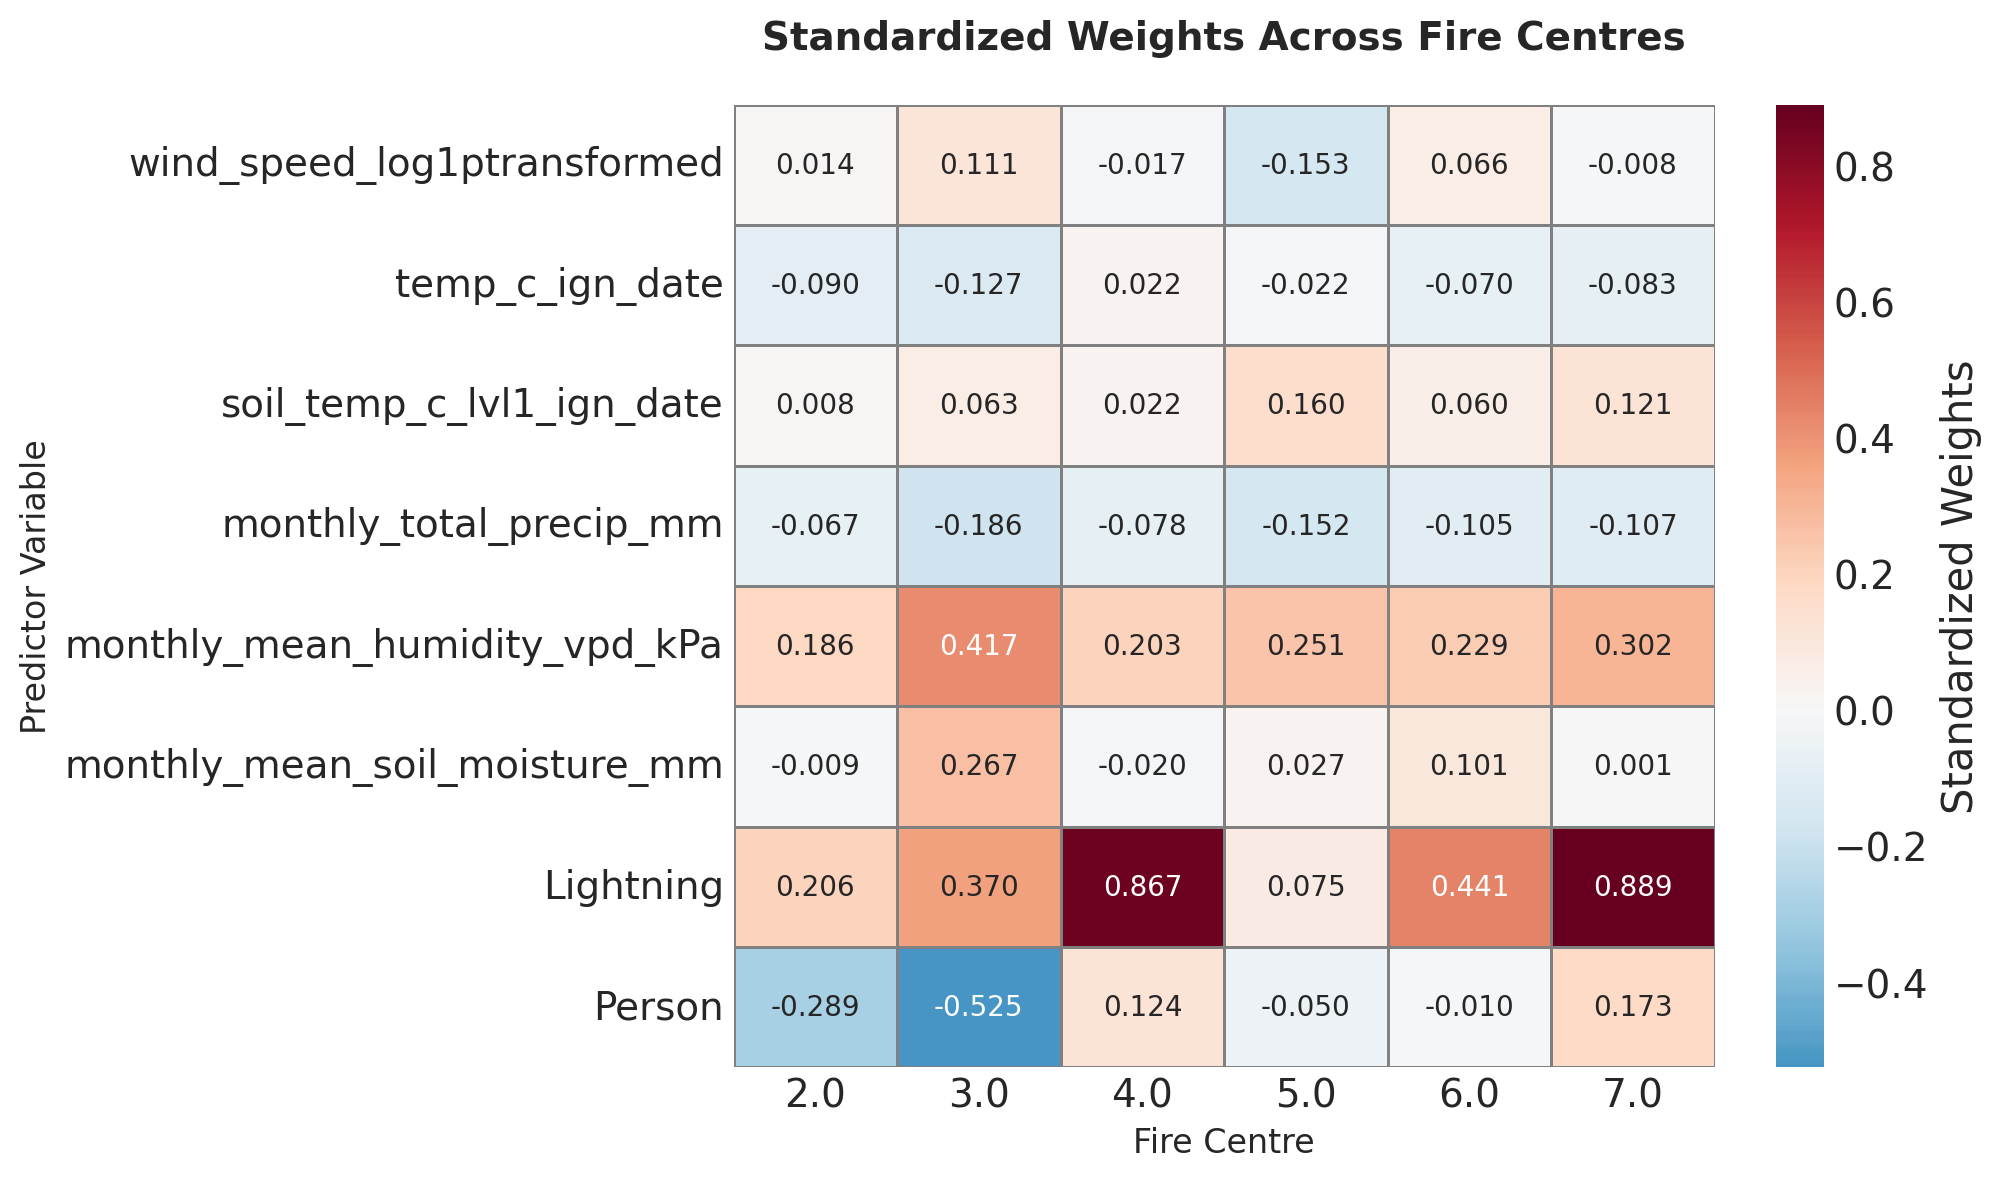

In [30]:
plot_zone_model_results(results_df, predictor_cols_unstd)

Based on our results, it seems our instincts were right about the fact that our fire centres reveal something that our baseline model was hiding. From the bar graph on the top left titled *R2 Score by Fire Centre*, we can see that the R2 scores for every fire centre immediately outpreformed our baseline model (`0.067`) which clearly indicates that there are strong regional differences in our dataset. And if we average the individual fire centre scores, the resulting R2 score of `0.117` nearly doubles our original baseline score. Even though 89% of the variance in the dataset remains unexplained, two things are made clear from this outcome. The first is that we need to gather more data to improve our model’s predictive capabilities. The other is that our data seems to display multi-level or hierarchical characteristics where the observations can be organized into clear groups where the predictor weights vary greatly between groups. Also based on the graph in the top right, there doesn’t seem to be a relationship between sample size and predictive accuracy as the R2 score in most zones sat pretty close to the mean.

Moving to the bottom graph, our *Standardized Weights Across Fire Centres* heatmap perfectly encapsulates these between group differences based on the range of values that populate this visual. Take our strongest predictor, lightning, as an example. Across the six fire centres in our dataset, its standardized weight ranged from `0.074` to `0.905` suggesting its association with fire size varies dramatically depending on the region! This result was also consistent with the high degree of uncertainty displayed in the Bayesian forest plot.

Another revealing insight was the consistency of humidity and precipitation as predictors across all zones where humidity reliably predicted positive effects, while precipitation reliably predicted negative ones. Temperature is also consistently negative across all zones, which contradicts our original DAG hypothesis of a strong positive effect, while soil temperature is effectively zero in five of six zones.

## **Updating our DAG based on the evidence**

Now that we’ve seen what two different modelling frameworks have to say about our original causal hypothesis, let’s pause to ask ourselves what the evidence encourages us to revise in our hypothetical DAG and why, given our atmospheric predictors. To properly revise our causal model requires providing coherent argument across multiple lines of evidence rather than just deleting whatever produced an inconsequential weight in our regression. Regression alone can't establish causation. But it can tell us whether the associations we observe are consistent with the causal story that our DAG proposes and whether removing hypothesized mediators changes our estimates in ways the DAG would predict. So with all that said, what did the evidence tell us?

For starters, soil moisture registered near-zero weights in four of the six fire centres in our Frequentist model. In the Bayesian regression model, its posterior was pulled almost entirely back to zero despite the prior being centred at -1, meaning 4,000 observations of large BC wildfires left essentially no trace of soil moisture's independent effect once the other predictors were included. And as we’ll see shortly, if we drop it, and soil temperature, from our updated regression model, the R² will barely move. Given that three converging lines of evidence point to the same conclusion, we can be confident that soil moisture has no detectable independent effect in this dataset, conditional on the other predictors, so we can remove it as a simplifying assumption.

Soil temperature tells a similar story here as its weights were also near-zero in four of the six fire centres in our dataset. In addition, soil temperature was highly collinear with temperature in our correlation matrix which was the strongest inter-predictor correlation in the entire plot. With no independent contribution to fire size and its variance already captured by upstream predictors, we can remove it from the DAG entirely as it's potentially a redundant predictor.

Let's test both decisions empirically by re-fitting the Frequentist Multiple Linear Regression model without these two predictors:

In [31]:
continuous_cols_v2 = [
    "wind_speed_log1ptransformed",
    "temp_c_ign_date",
    "monthly_total_precip_mm",
    "monthly_mean_humidity_vpd_kPa"
  ]

dummy_cols_v2 = [
    "Lightning",
    "Person"
]

results_df2, all_predictions2 = fit_zone_models_with_metrics(
    df=large_fire_df,
    continuous_cols=continuous_cols_v2,
    dummy_cols=dummy_cols_v2,
    target_col=target_col,
    zone_col="FRCNTR"
)

FIRE ZONE REGRESSION ANALYSIS

────────────────────────────────────────────────────────────────────────────────
FIRE ZONE 2.0 | n = 343
────────────────────────────────────────────────────────────────────────────────

📊 Model Performance:
   R² Score:  0.1041
   RMSE:      1.08 hectares

📈 Standardized Weights (effect of 1 SD increase):
   wind_speed_log1ptransformed        :   0.0149 ↑
   temp_c_ign_date                    :  -0.0851 ↓
   monthly_total_precip_mm            :  -0.0710 ↓
   monthly_mean_humidity_vpd_kPa      :   0.1871 ↑
   Lightning                          :   0.2143 ↑
   Person                             :  -0.2845 ↓

────────────────────────────────────────────────────────────────────────────────
FIRE ZONE 3.0 | n = 406
────────────────────────────────────────────────────────────────────────────────

📊 Model Performance:
   R² Score:  0.1143
   RMSE:      1.61 hectares

📈 Standardized Weights (effect of 1 SD increase):
   wind_speed_log1ptransformed        :   0.15

/tmp/ipykernel_4395/639628470.py:74: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


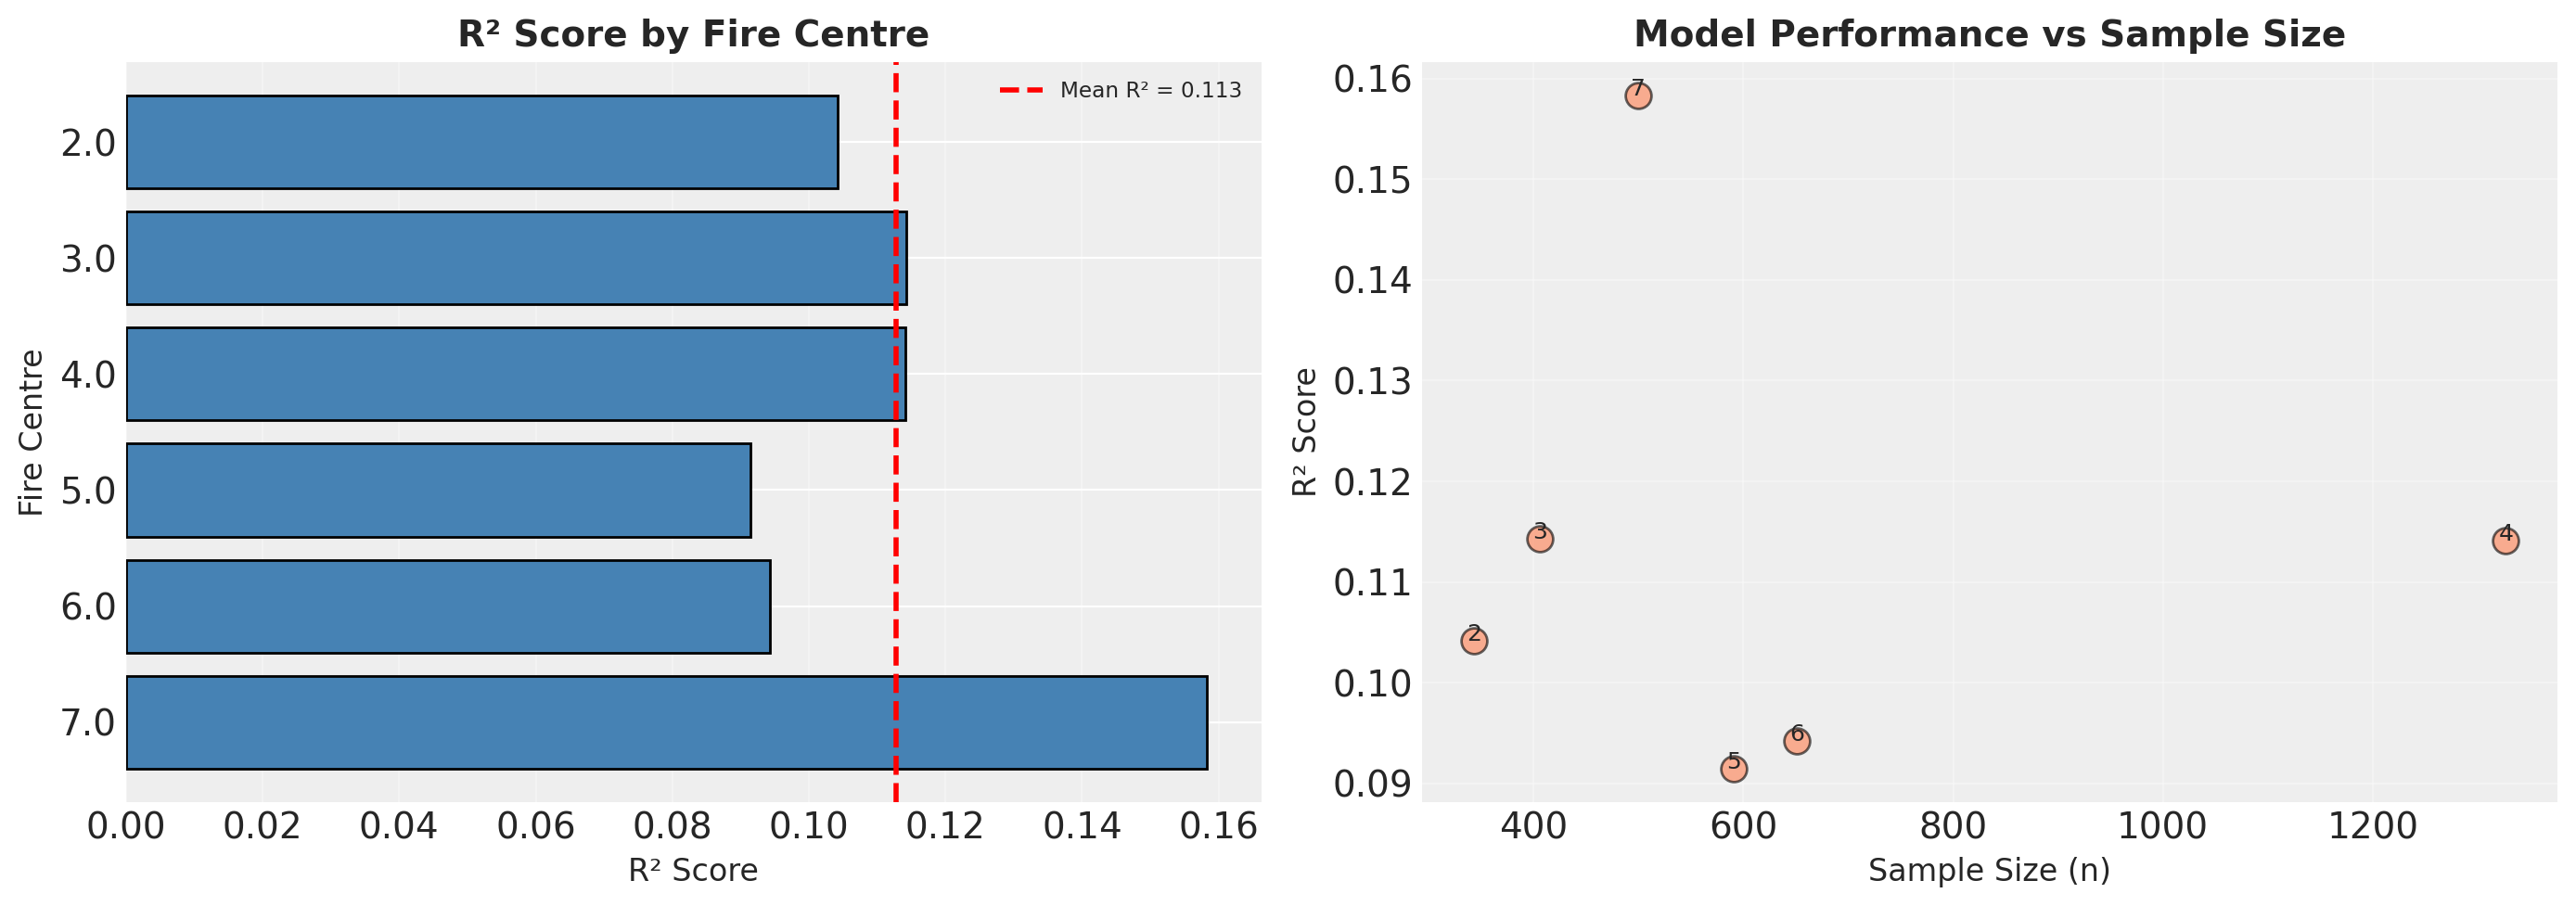

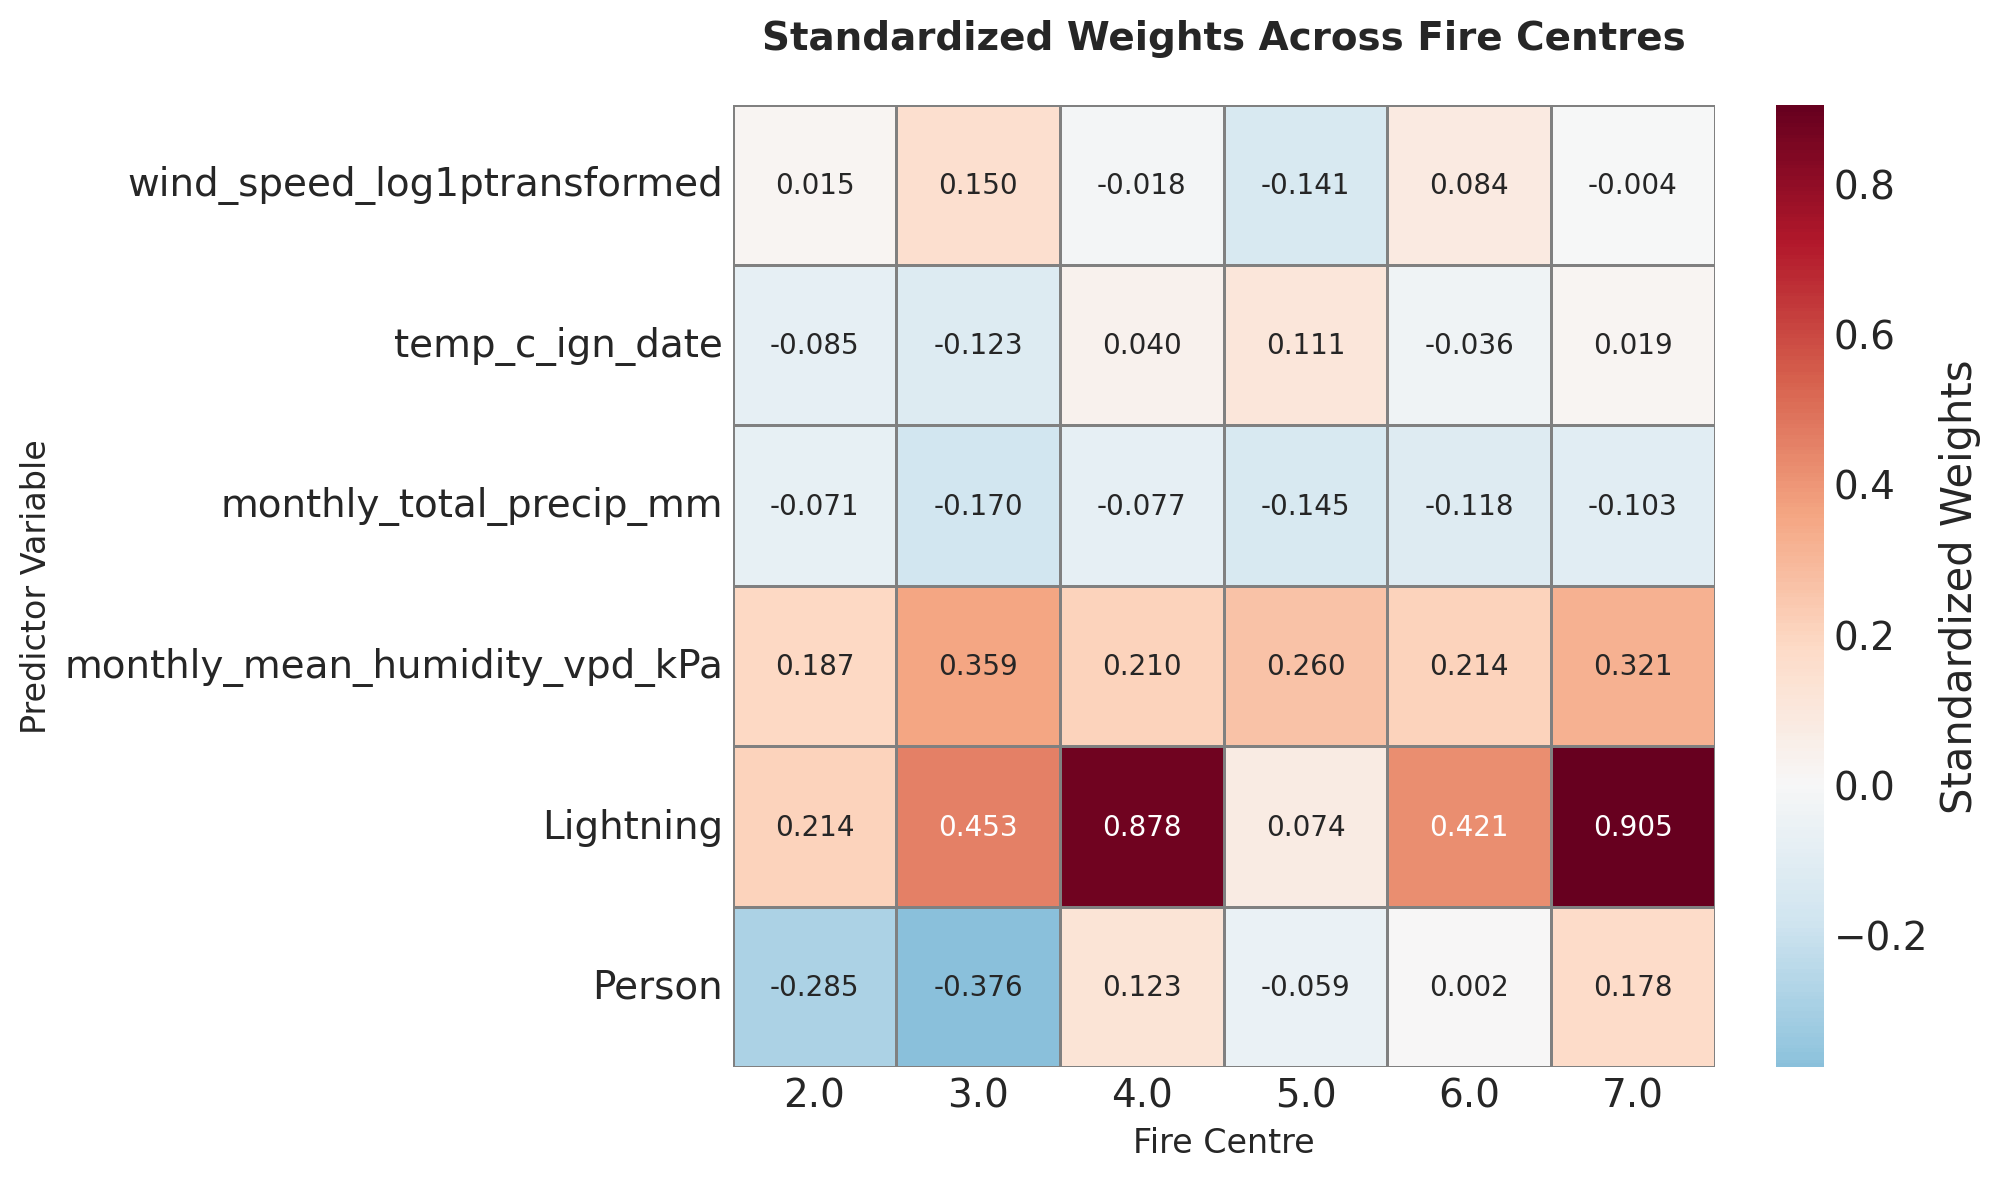

In [32]:
predictor_cols_unstd_v2 = continuous_cols_v2 + dummy_cols_v2

plot_zone_model_results(results_df2, predictor_cols_unstd_v2)

With soil temperature and soil moisture removed, our mean R² across fire centres dropped from `0.117` to `0.113` which is a four-tenths of a 1% drop in variance explained! The model lost almost nothing by dropping two predictors, thus signalling the redundancy of the mediators that were borrowing explanatory power from variables upstream of them rather than contributing their own. Dropping a true mediator should leave R² roughly unchanged if its upstream predictors are already in the model because the mediator carries no independent variance.

Two other revisions are worth making to the DAG based on what we observed across the **zone-level regression model**. Wind speed's signal remains inconsistent between fire centres suggesting that its relationship to fire size is geographically conditioned rather than uniformly directional. We've downgraded its arrow in the DAG from a strong positive to a moderate positive effect to reflect this instability.

Temperature also displayed a consistently small effect on fire size across all zones where no zone exceeded an absolute weight of `0.02` and half of them showed a slightly positive effect while the other half showed a slightly negative effect. The defensible interpretation of temperature on fire growth would be that it operates primarily through its effect on humidity. Higher temperatures will lead to higher humidity VPD levels, which in turn dries out fuels and creates the atmospheric conditions ripe for large fires. Therefore, we've re-coded that relationship in the updated DAG as a moderate positive arrow from temperature to humidity.

Here's what our revised causal DAG looks like after incorporating the evidence:

/tmp/ipykernel_4395/1374506364.py:155: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


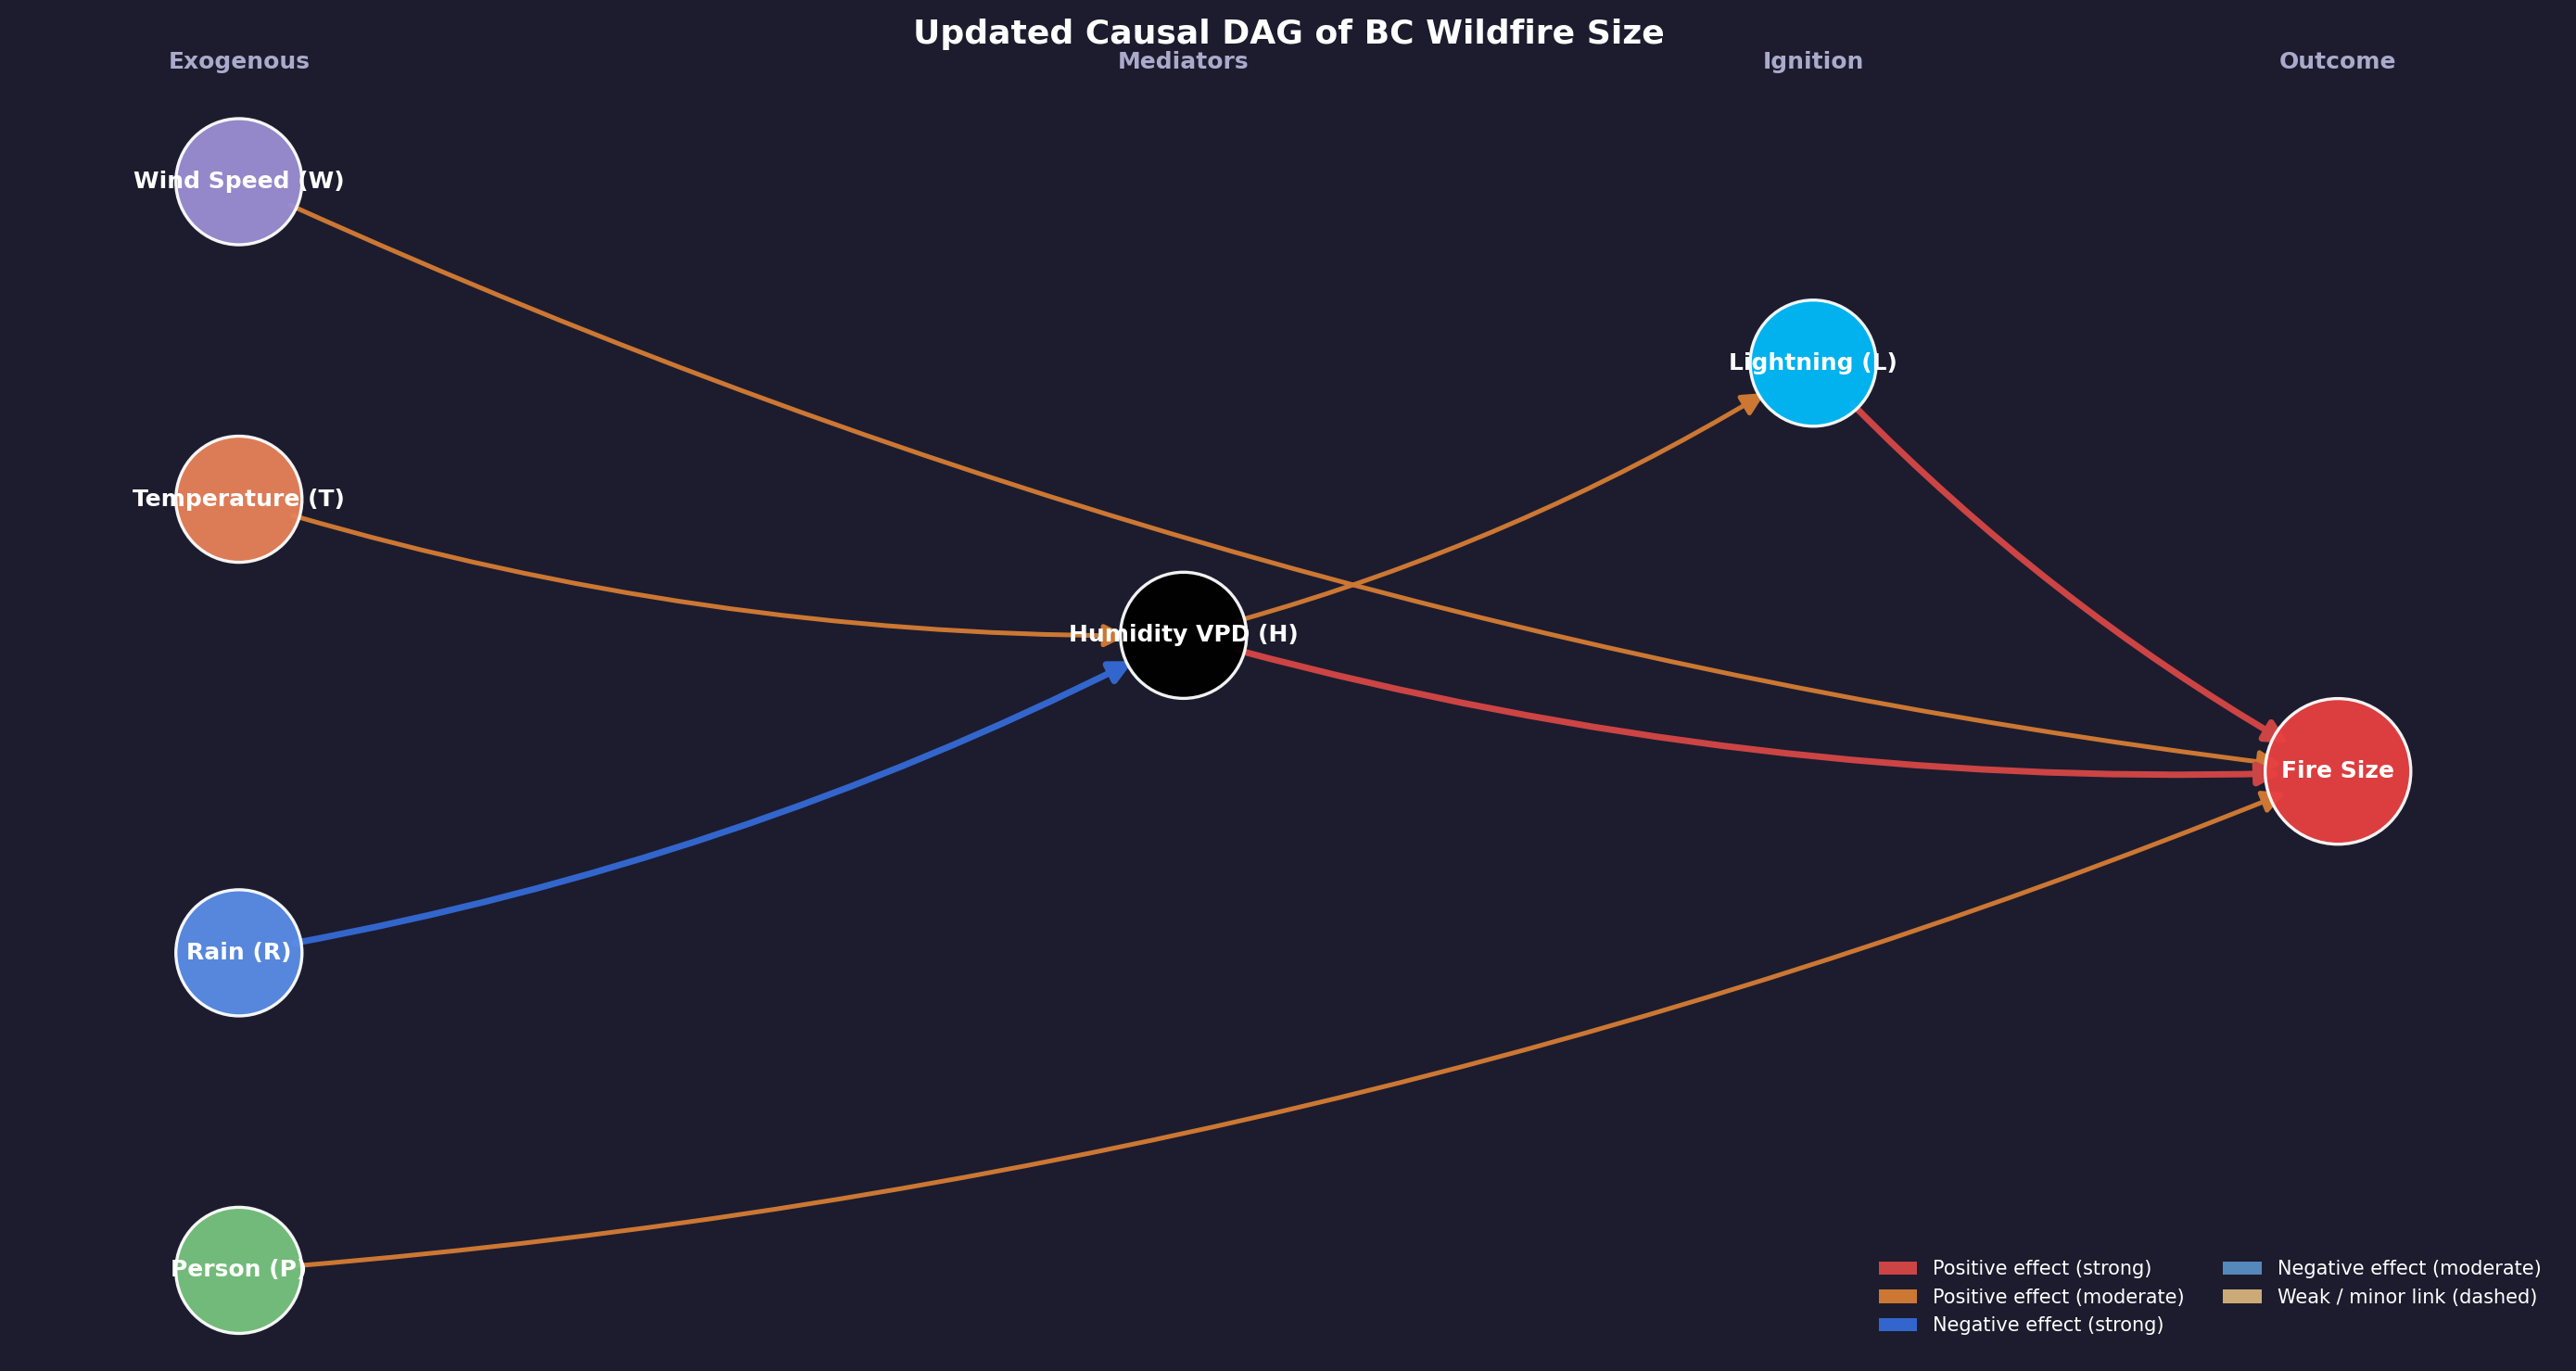

In [33]:
# ── Build the DAG ─────────────────────────────────────────────────────────────
G = nx.DiGraph()

# Node groups
exogenous   = ["Temperature (T)", "Rain (R)", "Wind Speed (W)", "Person (P)"]
mediators   = ["Humidity VPD (H)"]
ignition    = ["Lightning (L)"]
outcome     = ["Fire Size"]

all_nodes = exogenous + mediators + ignition + outcome
G.add_nodes_from(all_nodes)

# Edges: (source, target, sign, strength)
edges = [
    # Temperature pathways
    ("Temperature (T)",   "Humidity VPD (H)", "+", "moderate"),

    # Precipitation pathways
    ("Rain (R)", "Humidity VPD (H)", "-", "strong"),

    # VPD downstream
    ("Humidity VPD (H)", "Lightning (L)",      "+", "moderate"),

    # Direct effects on Fire Size
    ("Wind Speed (W)",      "Fire Size",    "+", "moderate"),
    ("Humidity VPD (H)", "Fire Size",    "+", "strong"),
    ("Lightning (L)",       "Fire Size",    "+", "strong"),
    ("Person (P)",          "Fire Size",    "+", "moderate"),
]

for src, tgt, sign, strength in edges:
    G.add_edge(src, tgt, sign=sign, strength=strength)

# ── Layout ────────────────────────────────────────────────────────────────────
# Manual positions for legibility
pos = {
    # Exogenous — left column
    "Temperature (T)":    (0.0, 0.75),
    "Rain (R)":  (0.0, 0.25),
    "Wind Speed (W)":     (0.0, 1.10),
    "Person (P)":         (0.0, -0.10),

    # Mediators — centre column
    "Humidity VPD (H)":            (0.45, 0.60),

    # Ignition — right-centre
    "Lightning (L)":      (0.75, 0.90),

    # Outcome — far right
    "Fire Size":      (1.0,  0.45),
}

# ── Colours & style ───────────────────────────────────────────────────────────
node_colours = {
    "Temperature (T)":     "#E8825A",
    "Rain (R)":            "#5A8EE8",
    "Wind Speed (W)":      "#9B8FD4",
    "Person (P)":          "#78C47E",
    "Humidity VPD (H)":    "#000000",
    "Lightning (L)":       "#00BBFA",
    "Fire Size":           "#E84040",
}

edge_colours = {
    ("+", "strong"):   "#CC4444",
    ("+", "moderate"): "#CC7733",
    ("+", "weak"):     "#CCAA77",
    ("-", "strong"):   "#3366CC",
    ("-", "moderate"): "#5588BB",
    ("-", "weak"):     "#88AACC",
}

edge_styles = {
    "strong":   "solid",
    "moderate": "solid",
    "weak":     "dashed",
}

edge_widths = {"strong": 2.5, "moderate": 1.8, "weak": 1.2}

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7.5))
fig.patch.set_facecolor("#1C1C2E")
ax.set_facecolor("#1C1C2E")

# Draw nodes
nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_size=[3200 if n == "Fire Size" else 2400 for n in G.nodes()],
    node_color=[node_colours[n] for n in G.nodes()],
    edgecolors="#FFFFFF", linewidths=1.2,
    alpha=0.95,
)

# Draw edges individually to control style
for src, tgt, data in G.edges(data=True):
    sign     = data["sign"]
    strength = data["strength"]
    colour   = edge_colours[(sign, strength)]
    style    = edge_styles[strength]
    width    = edge_widths[strength]

    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edgelist=[(src, tgt)],
        edge_color=colour,
        style=style,
        width=width,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=18,
        connectionstyle="arc3,rad=0.08",
        min_source_margin=22,
        min_target_margin=22,
    )

# Labels
nx.draw_networkx_labels(
    G, pos, ax=ax,
    font_size=9,
    font_color="#FFFFFF",
    font_weight="bold",
)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(facecolor="#CC4444", label="Positive effect (strong)"),
    mpatches.Patch(facecolor="#CC7733", label="Positive effect (moderate)"),
    mpatches.Patch(facecolor="#3366CC", label="Negative effect (strong)"),
    mpatches.Patch(facecolor="#5588BB", label="Negative effect (moderate)"),
    mpatches.Patch(facecolor="#CCAA77", label="Weak / minor link (dashed)")
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=7.5,
    framealpha=0.25,
    facecolor="#2A2A40",
    edgecolor="#FFFFFF",
    labelcolor="#FFFFFF",
    ncol=2,
)

# Column annotations
for x, label in [(0.0, "Exogenous"), (0.45, "Mediators"), (0.75, "Ignition"), (1.0, "Outcome")]:
    ax.text(x, 1.22, label, ha="center", va="bottom", fontsize=9,
            color="#AAAACC", fontweight="bold", transform=ax.transData)

ax.set_title(
    "Updated Causal DAG of BC Wildfire Size",
    color="#FFFFFF", fontsize=13, fontweight="bold", pad=20,
)
ax.axis("off")
plt.tight_layout()

With the removal of two predictors and the revision of a few relationships, our updated DAG becomes a simpler, more honest representation of how our data was generated given the atmospheric predictors we have to explain the variance. Lightning remains the dominant driver through its potential relationship to other confounding variables, humidity VPD is the most reliable continuous atmospheric predictor, and precipitation exerts a consistent dampening effect while the soil-based mediators were removed. In a sense, this entire process of building a causal hypothesis, confronting it with data, and revising the structure based on the evidence is the DAG equivalent of **Bayesian updating**! We started with a hypothesis/prior belief about how atmospheric conditions drive wildfire size, encoded it as a directed acyclic graph, and used our models as the likelihood function that told us where the data agreed and where it didn't. As a result, our revised DAG is our posterior belief. It’s not a declaration of truth, but a more calibrated belief about the data generating process given what we've observed.

## **Beyond Regression: Real-world implications and future directions**

We opened this article with a sobering picture of the conditions ahead of BC's 2026 fire season: A snowless winter, snowpack at a fraction of normal across every region of the province, and temperatures running ten degrees above seasonal averages in late April. Fire managers are already making resource allocation decisions such as where to pre-position crews or which regions to prioritize under genuine uncertainty. So what, if anything, does an R² of `0.11` tell someone trying to protect communities and ecosystems? Well based on our analysis, perhaps more than what meets the eye.

Our models confirmed that humidity is the most geographically consistent atmospheric signal in the dataset as it was positive across all six fire centres even when effect sizes varied. For fire managers, this is an actionable insight because humidity is a monitored, forecastable variable. Regions experiencing sustained levels of high humidity combined with the kind of depleted snowpack we've seen in 2026 signals an elevated risk in exactly the way our models would predict.

Another insight that our analysis confirmed was that rain had a consistently negative effect on wildfire size across all fire centres which matches what intuition would tell us. Regardless of our priors on this finding, at the very least we can be confident that our models reinforce the operational intuition that rain is the primary atmospheric dampener of the conditions that allow fires to grow past the 100 hectare threshold we analyzed. Perhaps wildfire managers and emergency responders can find some solace in the BC Wildfire Service's own spring outlook forecasting that potential precipitation in May and June will play a key role in the severity of the fire season ahead.

Although our atmospheric predictors were able to provide some value in helping us understand the causal structure of wildfires burning over 100 hectares, perhaps the most telling finding is what they couldn't explain. Given that our  **zone-based Frequentist Multiple Linear Regression** model was only 11% of the variance in the dataset, that leaves a massive gap of 89% of the variance left unaccounted for! Unfortunately, this isn't just noise but structural issues we don't yet have data to capture.

Lightning's dominant predictive effect likely carries a confounding story about remoteness. Our theory here is that whenever fires ignite far from roads, fire halls, and population centres, they are detected later, reported later, and suppressed later. By the time firefighters can coordinate a response, the fire might have already grown to a size that’s exponentially harder to control. So with this line of reasoning, it’s possible that ignition distance from human infrastructure, whether that’s the nearest highway, the nearest fire hall, or the nearest community, may be one of the highest-value predictors to add to a future version of this analysis. It's quantifiable, it's spatially available, and based on our results, it's probably doing a lot of the work currently attributed to lightning as a cause.

The zone-level analysis also produced a structural finding that went beyond our atmospheric predictors: That British Columbia's fire behaviour doesn't obey a single causal structure. The fact that the same predictor behaves so differently across fire centres was a key signal that fitting a single global model was actively hiding that heterogeneity. What's likely the right response to these subpopulation differences is to fit a hierarchical or multilevel model that allows predictor weights to vary by fire centre while still estimating province-wide patterns. Testing which models are most suited to explain our data is the natural next step for this project and would likely recover a meaningful portion of the unexplained variance along with more data.

As we touched on earlier, other high-priority additions to a future dataset would include suppression response time from ignition to first attack, terrain and slope at the ignition point, fuel type and load at ignition, and fire weather conditions during the burn rather than only at ignition. We should emphasize that last point because if you recall from part 1, almost half our predictors captured atmospheric conditions on the day the fire started, not the days it actually burned. A fire that ignites on a mild day and then burns into a heat dome will be systematically underestimated by ignition-date predictors alone. Adding fire weather during the active burn period would likely be the single largest improvement to predictive accuracy available to us.

While there's a lot of areas we can improve on, the important thing to remember is that what we've built here is a foundation, not a forecast. The updated causal DAG is a more honest representation of what atmospheric data can tell us about large fires in BC such as which variables matter, which don't, and how the causal structure likely differs by geography. For a fire season already shaping up to be one of the most dangerous in recent memory, understanding even that much is a better starting point than assuming all predictors matter equally or that a single province-wide model captures the truth. The work ahead is to fill in what's missing. The causal framework we've established here tells us exactly where to look.

# **References**

- BC Wildfire Service. (2026, April 16). Spring 2026 seasonal outlook. *Government of British Columbia*. [https://blog.gov.bc.ca/bcwildfire/spring-2026-seasonal-outlook/](https://blog.gov.bc.ca/bcwildfire/spring-2026-seasonal-outlook/)

- Du, K. & Nair, Y. (2025). *Bernstein–von Mises for adaptively collected data*. arXiv. [https://arxiv.org/html/2511.06639](https://arxiv.org/html/2511.06639)

- Gelineau, J. (2026, May 6). Elevated drought risk in southern B.C., according to latest snowpack report. *CBC News*. [https://www.cbc.ca/news/canada/british-columbia/drought-risk-may-2026-river-forecast-centre-snowpack-9.7193316](https://www.cbc.ca/news/canada/british-columbia/drought-risk-may-2026-river-forecast-centre-snowpack-9.7193316)

- McElreath, R. (2020). *Statistical Rethinking: A Bayesian Course with examples in R and Stan*. Routledge.

- Shepert, E.  (2026, April 29). Metro Vancouver weather: Temperatures to soar to 28 C. But how long will they last? *Vancouver Is Awesome*.
[https://www.vancouverisawesome.com/local-news/vancouver-weather-temperatures-soar-storm-2026-12211507](https://www.vancouverisawesome.com/local-news/vancouver-weather-temperatures-soar-storm-2026-12211507 )